In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
orders = pd.read_csv("../Data_Cleaning/olist_orders_dataset_cleaned.csv")
customers = pd.read_csv("../Data_Cleaning/olist_customers_dataset_cleaned.csv")
order_items = pd.read_csv("../Data_Cleaning/olist_order_items_dataset_cleaned.csv")
products = pd.read_csv("../Data_Cleaning/olist_products_dataset_cleaned.csv")
translation = pd.read_csv("../Data_Cleaning/product_category_name_translation.csv")

In [4]:
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])

#### ✅ What percentage of orders are delivered late?

In [5]:
# Take only the orders that their status is delivered
fi = orders["order_status"] == "delivered"
delivered = orders[fi]
delivered.shape

(96267, 8)

In [6]:
# I used normlized in order to ignore the time just the date
delivered_day = delivered["order_delivered_customer_date"].dt.normalize()
delivered_day.head()

0   2017-10-10
1   2018-08-07
2   2018-08-17
3   2017-12-02
4   2018-02-16
Name: order_delivered_customer_date, dtype: datetime64[ns]

In [7]:
fi1 = delivered_day > delivered["order_estimated_delivery_date"]
fi1.value_counts()

False    89736
True      6531
Name: count, dtype: int64

In [8]:
late_percentage = fi1.mean() * 100
late_percentage

np.float64(6.784256287201222)

#### ✅ Is the delay pattern consistent (e.g., certain months, weekends, or quarters)?

##### By quarter

In [9]:
# Convert the dates to datetime
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [10]:
orders["IS LATE"] = (
    orders["order_delivered_customer_date"] >
    orders["order_estimated_delivery_date"]
)

In [11]:
orders["QUARTER"] = orders["order_purchase_timestamp"].dt.to_period("Q")

In [12]:
by_quarter = orders.groupby("QUARTER")["IS LATE"].mean() * 100
by_quarter = by_quarter.drop(["2016Q3", "2018Q4"])
by_quarter

QUARTER
2016Q4     0.934579
2017Q1     4.157132
2017Q2     4.600899
2017Q3     3.856509
2017Q4     9.760744
2018Q1    14.188042
2018Q2     5.022119
2018Q3     7.334119
Freq: Q-DEC, Name: IS LATE, dtype: float64

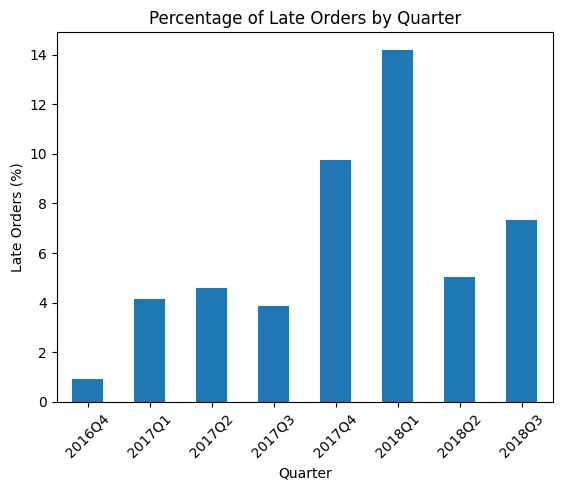

In [13]:
by_quarter.plot(kind="bar")

plt.title("Percentage of Late Orders by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Late Orders (%)")
plt.xticks(rotation=45)
plt.show();

#### ✅ Does lateness occur even when the seller and customer are in the same state?

In [15]:
sellers = pd.read_csv("../Data_Cleaning/olist_sellers_dataset_cleaned.csv")

In [16]:
same_state_data = orders.merge(order_items[["order_id", "seller_id"]],on="order_id")
same_state_data = same_state_data.merge(customers[["customer_id", "customer_state"]],on="customer_id")
same_state_data = same_state_data.merge(sellers[["seller_id", "seller_state"]],on="seller_id")

same_state_data["IS LATE"] = (same_state_data["order_delivered_customer_date"] >same_state_data["order_estimated_delivery_date"])

In [17]:
same_state = same_state_data[same_state_data["seller_state"] == same_state_data["customer_state"]]

In [18]:
same_state["IS LATE"].value_counts()

IS LATE
False    38281
True      2382
Name: count, dtype: int64

In [19]:
same_state["IS LATE"].value_counts(normalize=True) * 100

IS LATE
False    94.142095
True      5.857905
Name: proportion, dtype: float64

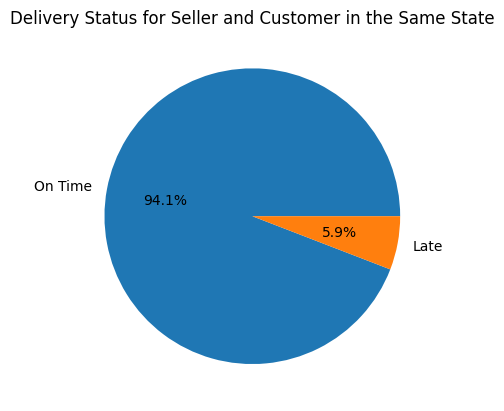

In [20]:
same_state_status = same_state["IS LATE"].value_counts()

same_state_status.index = same_state_status.index.map({
    False: "On Time",
    True: "Late"
})

same_state_status.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Delivery Status for Seller and Customer in the Same State")
plt.ylabel("")
plt.show();

#### ✅ Does order weight, size, or product type influence delivery delays?

##### By weight

In [21]:
delivery_product = orders.merge(order_items[["order_id", "product_id"]],on="order_id")
delivery_product = delivery_product.merge(products,on="product_id")

In [22]:
delivery_product["WEIGHT KG"] = (delivery_product["product_weight_g"] / 1000)

In [23]:
delivery_product["WEIGHT KG"].describe()

count    112367.000000
mean          2.094048
std           3.752490
min           0.000000
25%           0.300000
50%           0.700000
75%           1.800000
max          40.425000
Name: WEIGHT KG, dtype: float64

In [24]:
weight_bins = [0, 5, 15, 25, 45]
weight_labels = ["0-5 kg", "5-15 kg", "15-25 kg", "25-45 kg"]

delivery_product["WEIGHT GROUP"] = pd.cut(delivery_product["WEIGHT KG"],bins=weight_bins, labels=weight_labels)

In [25]:
delivery_product["IS LATE"] = (delivery_product["order_delivered_customer_date"] >
    delivery_product["order_estimated_delivery_date"])

In [26]:
weight_delay = (delivery_product.groupby("WEIGHT GROUP")["IS LATE"].mean() * 100)

weight_delay

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37640\4112616067.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_delay = (delivery_product.groupby("WEIGHT GROUP")["IS LATE"].mean() * 100)


WEIGHT GROUP
0-5 kg       7.626628
5-15 kg      8.166985
15-25 kg    10.706751
25-45 kg    12.387387
Name: IS LATE, dtype: float64

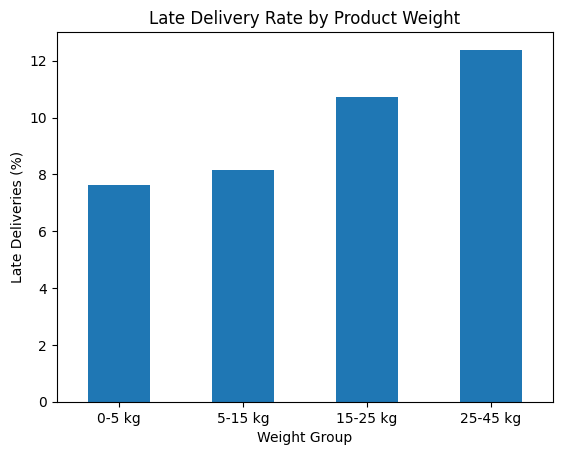

In [27]:
weight_delay.plot(kind="bar")

plt.title("Late Delivery Rate by Product Weight")
plt.xlabel("Weight Group")
plt.ylabel("Late Deliveries (%)")
plt.xticks(rotation=360)
plt.show();

##### By size

In [28]:
delivery_product["VOLUME CM3"] = (delivery_product["product_length_cm"] *
delivery_product["product_width_cm"] * delivery_product["product_height_cm"])

In [29]:
delivery_product["VOLUME CM3"].describe()

count    112367.000000
mean      15248.663398
std       23428.975534
min         168.000000
25%        2850.000000
50%        6480.000000
75%       18375.000000
max      296208.000000
Name: VOLUME CM3, dtype: float64

In [30]:
delivery_product["VOLUME CM3"].describe()

count    112367.000000
mean      15248.663398
std       23428.975534
min         168.000000
25%        2850.000000
50%        6480.000000
75%       18375.000000
max      296208.000000
Name: VOLUME CM3, dtype: float64

In [31]:
size_bins = [0, 5000, 10000, 20000, 50000, 100000, 300000]
size_labels = ["0 - 5K", "5K - 10K", "10K - 20K", "20K - 50K", "50K - 100K", "100K - 300K"]

delivery_product["SIZE GROUP"] = pd.cut(delivery_product["VOLUME CM3"], bins=size_bins, labels=size_labels)

In [32]:
size_delay = (delivery_product.groupby("SIZE GROUP", observed=True)["IS LATE"].mean() * 100)
size_delay

SIZE GROUP
0 - 5K         7.686003
5K - 10K       7.191814
10K - 20K      7.844725
20K - 50K      7.837918
50K - 100K     9.165950
100K - 300K    9.912718
Name: IS LATE, dtype: float64

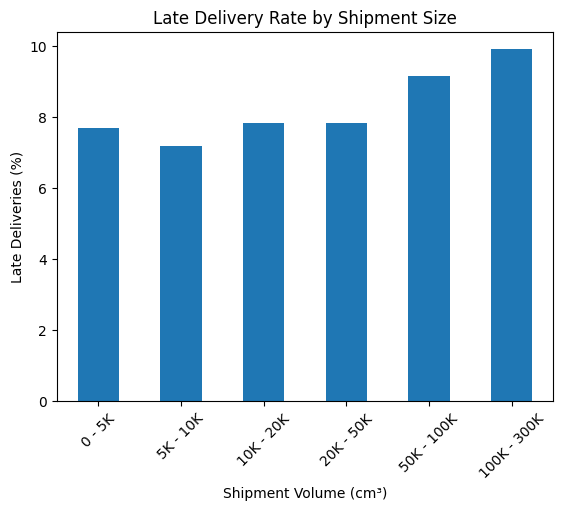

In [33]:
size_delay.plot(kind="bar")

plt.title("Late Delivery Rate by Shipment Size")
plt.xlabel("Shipment Volume (cm³)")
plt.ylabel("Late Deliveries (%)")
plt.xticks(rotation=45)
plt.show()

#### ✅ What is the average delay duration, and how does it vary by state?

##### Average

In [34]:
# creat the delay_days col to store delay days
delivered["delay_days"] = (delivered_day - delivered["order_estimated_delivery_date"]).dt.days
delivered["delay_days"].head()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37640\2056719774.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  delivered["delay_days"] = (delivered_day - delivered["order_estimated_delivery_date"]).dt.days


0    -8
1    -6
2   -18
3   -13
4   -10
Name: delay_days, dtype: int64

In [35]:
late = delivered[fi1]
late.shape

(6531, 9)

In [36]:
late["delay_days"].mean()

np.float64(10.623028632674934)

##### By state

In [37]:
late_states = pd.merge(late, customers, on="customer_id", how="inner")

In [38]:
by_state = late_states.groupby("customer_state")["delay_days"].agg(["mean"])
by_state.sort_values("mean", ascending=False)

,mean
customer_state,
AP,72.500000
RR,36.400000
AM,30.250000
AC,18.666667
SE,16.196078
CE,15.181818
RN,14.477273
international,13.727273
RJ,13.498658


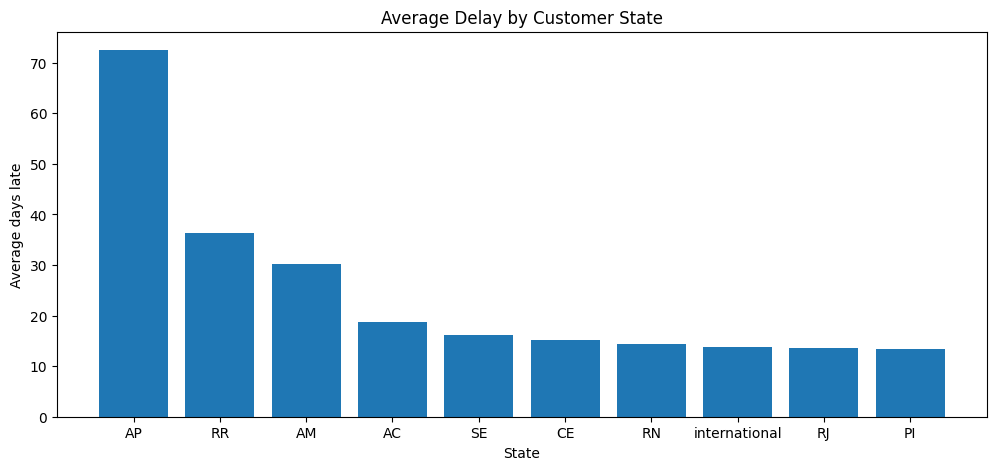

In [39]:
by_state = by_state.sort_values("mean", ascending=False).head(10)

plt.figure(figsize=(12, 5))
plt.bar(by_state.index, by_state["mean"])
plt.title("Average Delay by Customer State")
plt.xlabel("State")
plt.ylabel("Average days late")
plt.show();

##### By product category

In [40]:
late_products = pd.merge(late, order_items, on="order_id", how="inner")
late_products = pd.merge(late_products, products, on="product_id", how="inner")
late_products = pd.merge(late_products, translation, on="product_category_name", how="inner")

In [41]:
by_category = late_products.groupby("product_category_name_english")["delay_days"].agg(["mean"])
by_category.sort_values("mean", ascending=False).head(10)

,mean
product_category_name_english,
home_appliances_2,21.928571
food_drink,18.454545
music,18.000000
furniture_mattress_and_upholstery,15.200000
signaling_and_security,14.750000
home_comfort_2,14.500000
air_conditioning,14.363636
drinks,14.125000
home_confort,12.975000


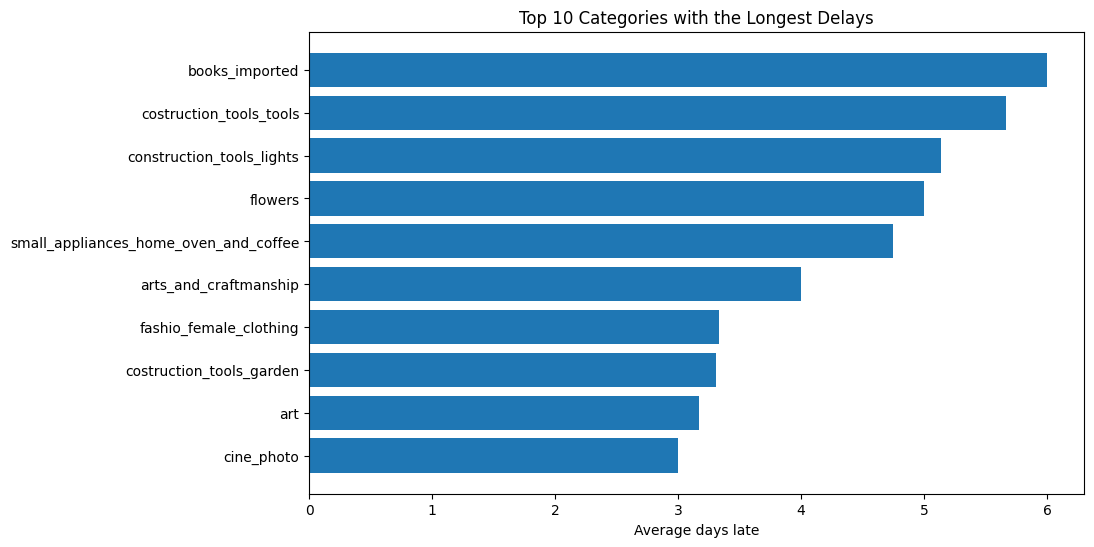

In [42]:
top10_categories = by_category.sort_values(by="mean").head(10)
plt.figure(figsize=(10, 6))
plt.barh(top10_categories.index, top10_categories["mean"])
plt.title("Top 10 Categories with the Longest Delays")
plt.xlabel("Average days late")
plt.show()

##### By order size

In [43]:
delivery_product["DELAY DAYS"] = (
    delivery_product["order_delivered_customer_date"] -
    delivery_product["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [44]:
late_orders = delivery_product[delivery_product["DELAY DAYS"] > 0]

In [45]:
size_avg_delay = (late_orders.groupby("SIZE GROUP", observed=True)["DELAY DAYS"].mean())
size_avg_delay

SIZE GROUP
0 - 5K          8.848722
5K - 10K        9.340173
10K - 20K      10.694308
20K - 50K       8.965566
50K - 100K     10.932052
100K - 300K    11.306990
Name: DELAY DAYS, dtype: float64

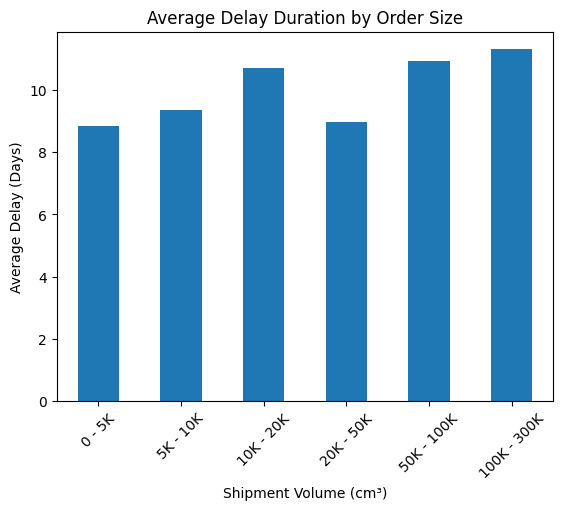

In [46]:
size_avg_delay.plot(kind="bar")

plt.title("Average Delay Duration by Order Size")
plt.xlabel("Shipment Volume (cm³)")
plt.ylabel("Average Delay (Days)")
plt.xticks(rotation=45)
plt.show()

### Part 4:

#### 1. Creating the tables that will be needed:

**Table One: orders and customers**

In [47]:
orders_df =pd.read_csv('../Data_Cleaning/olist_orders_dataset_cleaned.csv', parse_dates=['order_purchase_timestamp', 'order_approved_at' ,'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'])

In [48]:
customers_df = pd.read_csv('../Data_Cleaning/olist_customers_dataset_cleaned.csv')

In [49]:
orders_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [50]:
customers_df.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state', 'state_name'],
      dtype='object')

In [51]:
orders_customers_df = pd.merge(orders_df,customers_df, left_on='customer_id', right_on='customer_id', how='left')

In [52]:
orders_customers_df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
customer_unique_id                       object
customer_zip_code_prefix                  int64
customer_city                            object
customer_state                           object
state_name                               object
dtype: object

In [53]:
orders_customers_df['delivery_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_purchase_timestamp']).dt.days

In [54]:
orders_customers_df['carrier_delivery_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_delivered_carrier_date']).dt.days

In [55]:
orders_customers_df['delay_days'] = (orders_customers_df['order_delivered_customer_date'] - orders_customers_df['order_estimated_delivery_date']).dt.days

In [56]:
orders_customers_df['is_late'] = orders_customers_df['delay_days'] > 0

**Table Two:**

In [57]:
orders_items_df = pd.read_csv('../Data_Cleaning/olist_order_items_dataset_cleaned.csv')

In [58]:
sellers_df = pd.read_csv('../Data_Cleaning/olist_sellers_dataset_cleaned.csv')

In [59]:
orders_items_df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [60]:
sellers_df.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name'],
      dtype='object')

- this table will be the combination of 3 tables:

In [61]:
items_order_df = pd.merge(orders_items_df, orders_customers_df, left_on='order_id', right_on = 'order_id', how='left' )

In [62]:
full_info_df = pd.merge(items_order_df, sellers_df, left_on='seller_id', right_on = 'seller_id', how= 'left')

In [63]:
full_info_df.columns

Index(['Unnamed: 0', 'order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name'],
      dtype='object')

In [64]:
full_info_df = full_info_df.drop(columns=['Unnamed: 0'])

**Table Three:**

In [65]:
geolocation_df = pd.read_csv('../Data_Cleaning/olist_geolocation_dataset_cleaned.csv')

In [66]:
geolocation_df.columns

Index(['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng',
       'geolocation_city', 'geolocation_state', 'state_name'],
      dtype='object')

-  we will group by zip code so to make it easier we'll group the df by zipcode as the lat and long for all duplicated zip codes slightly different we will take the mean: 

In [67]:
geo_grouped_df =  geolocation_df.groupby('geolocation_zip_code_prefix', as_index= False)[['geolocation_lat', 'geolocation_lng']].mean()

In [68]:
geo_customers = geo_grouped_df.rename(columns= {'geolocation_zip_code_prefix' : 'customer_zip_code_prefix', 'geolocation_lat' : 'customer_lat', 'geolocation_lng' : 'customer_lng'})

In [69]:
geo_sellers = geo_grouped_df.rename(columns= {'geolocation_zip_code_prefix' : 'seller_zip_code_prefix', 'geolocation_lat' : 'seller_lat', 'geolocation_lng' : 'seller_lng'})

In [70]:
#we will first merge the customers and align it with the full info table we created before
full_geo_df = pd.merge(full_info_df, geo_customers, left_on='customer_zip_code_prefix', right_on='customer_zip_code_prefix', how='left')

In [71]:
#them also merge the sellers:
full_geo_df = pd.merge(full_geo_df, geo_sellers, left_on='seller_zip_code_prefix', right_on='seller_zip_code_prefix', how='left')

In [72]:
full_geo_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,...,delay_days,is_late,seller_zip_code_prefix,seller_city,seller_state,seller_state_name,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,...,-9.0,False,27277,volta redonda,SP,Sao Paulo,-21.763186,-41.310265,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,...,-3.0,False,3471,sao paulo,SP,Sao Paulo,-20.222506,-50.898951,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,...,-14.0,False,37564,borda da mata,MG,Minas Gerais,-19.869998,-44.593059,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,...,-6.0,False,14403,franca,SP,Sao Paulo,-23.105968,-46.590277,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,...,-16.0,False,87900,loanda,PR,Parana,-23.243402,-46.827614,-22.929583,-53.135750


- we have a lot of NOT needed columns so we'll keep the ones we want only

In [73]:
full_geo_df.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng'],
      dtype='object')

In [74]:
full_geo_df = full_geo_df.drop(columns=['product_id', 'shipping_limit_date', 'order_approved_at', 'customer_unique_id',  'customer_zip_code_prefix', 'seller_zip_code_prefix'])

In [75]:
full_geo_df = full_geo_df.rename(columns= {'state_name': 'customer_state_name'})

In [76]:
full_geo_df.head()

,order_id,order_item_id,seller_id,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,...,carrier_delivery_days,delay_days,is_late,seller_city,seller_state,seller_state_name,customer_lat,customer_lng,seller_lat,seller_lng
0,00010242fe8c5a6d1ba2dd792cb16214,1,48436dade18ac8b2bce089ec2a041202,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-19 18:34:16,2017-09-20 23:43:48,...,1.0,-9.0,False,volta redonda,SP,Sao Paulo,-21.763186,-41.310265,-22.497188,-44.127324
1,00018f77f2f0320c557190d7a144bdd3,1,dd7ddc04e1b6c2c614352b383efe2d36,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-05-04 14:35:00,2017-05-12 16:04:24,...,8.0,-3.0,False,sao paulo,SP,Sao Paulo,-20.222506,-50.898951,-23.565754,-46.519097
2,000229ec398224ef6ca0657da4fc703e,1,5b51032eddd242adc84c38acab88f23d,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-16 12:36:48,2018-01-22 13:19:16,...,6.0,-14.0,False,borda da mata,MG,Minas Gerais,-19.869998,-44.593059,-22.262802,-46.170735
3,00024acbcdf0a6daa1e931b038114c75,1,9d7a1d34a5052409006425275ba1c2b4,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-10 13:28:00,2018-08-14 13:32:39,...,4.0,-6.0,False,franca,SP,Sao Paulo,-23.105968,-46.590277,-20.553651,-47.387145
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,df560393f3a51e74553ab94004ba5c87,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-16 09:46:09,2017-03-01 16:42:31,...,13.0,-16.0,False,loanda,PR,Parana,-23.243402,-46.827614,-22.929583,-53.135750


#### 2. Answering the Questions:

##### 1. Which states have customers but no sellers?

In [77]:
# finde the states that have sellers: 
sellers_states = sellers_df['seller_state'].unique()

In [78]:
sellers_states

array(['SP', 'RJ', 'PE', 'PR', 'GO', 'SC', 'BA', 'DF', 'RS', 'MG', 'RN',
       'MT', 'CE', 'PB', 'AC', 'ES', 'RO', 'PI', 'MS', 'SE', 'MA', 'AM',
       'PA'], dtype=object)

In [79]:
#the states that has customers:
customers_states = pd.Series(customers_df['customer_state'].unique())

In [80]:
#now check states that HAVE sellers and states the does NOT HAVE
has_sellers = customers_states.isin(sellers_states)
has_no_sellers = has_sellers == False

In [81]:
no_seller_states = customers_states[has_no_sellers] 

In [82]:
#to make sure we're checking only in brazil
no_seller_table = pd.DataFrame({
    'State': no_seller_states[
        no_seller_states != 'international'
    ].values
})
print(f"Number of states with customers but no sellers: {len(no_seller_table)}")
no_seller_table

Number of states with customers but no sellers: 4


,State
0,AP
1,AL
2,TO
3,RR


##### 2. How is the shipping company performing there? Are deliveries to these states without sellers delayed or on time?

In [83]:
delivered_orders = orders_customers_df[orders_customers_df['order_status'] == 'delivered'].copy()

In [84]:
delivered_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_name,delivery_days,carrier_delivery_days,delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Sao Paulo,8.0,6.0,-8.0,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Bahia,13.0,12.0,-6.0,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Goias,9.0,9.0,-18.0,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Rio Grande do Norte,13.0,9.0,-13.0,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Sao Paulo,2.0,1.0,-10.0,False


In [85]:
no_seller_orders = delivered_orders[delivered_orders['customer_state'].isin(no_seller_states)]

In [86]:
no_seller_state_summary = no_seller_orders.groupby('customer_state')[['delivery_days', 'carrier_delivery_days', 'delay_days']].mean()

In [87]:
no_seller_state_summary['late_%'] = no_seller_orders.groupby('customer_state')['is_late'].mean() * 100

In [88]:
late_only = no_seller_orders[no_seller_orders['is_late'] == True]

In [89]:
# because here we only need the internal shippings 
no_seller_state_summary = no_seller_state_summary.drop('international') 

In [90]:
national = delivered_orders[['delivery_days', 'carrier_delivery_days', 'delay_days']].mean()
national['late_%'] = delivered_orders['is_late'].mean() * 100
no_seller_state_summary.loc['All states'] = national

In [91]:
chart01_df = no_seller_state_summary[['delivery_days', 'carrier_delivery_days', 'delay_days']].copy()

In [92]:
chart01_df = chart01_df.rename(columns={'delivery_days': 'Total delivery time', 'carrier_delivery_days': 'Carrier delivery time', 'delay_days': 'Days vs. promised date (below 0 = early)'})

In [93]:
late_counts = late_only.groupby('customer_state').size()
total_counts = no_seller_orders['customer_state'].value_counts()

In [94]:
labels = []
for state in no_seller_state_summary.index:
    late = round(no_seller_state_summary.loc[state, 'late_%'], 1)
    if state == 'All states':
        labels.append(f'{state}\n{late}% late')
    else:
        labels.append(f'{state}\n{late}% late\n({late_counts[state]} of {total_counts[state]} orders)')

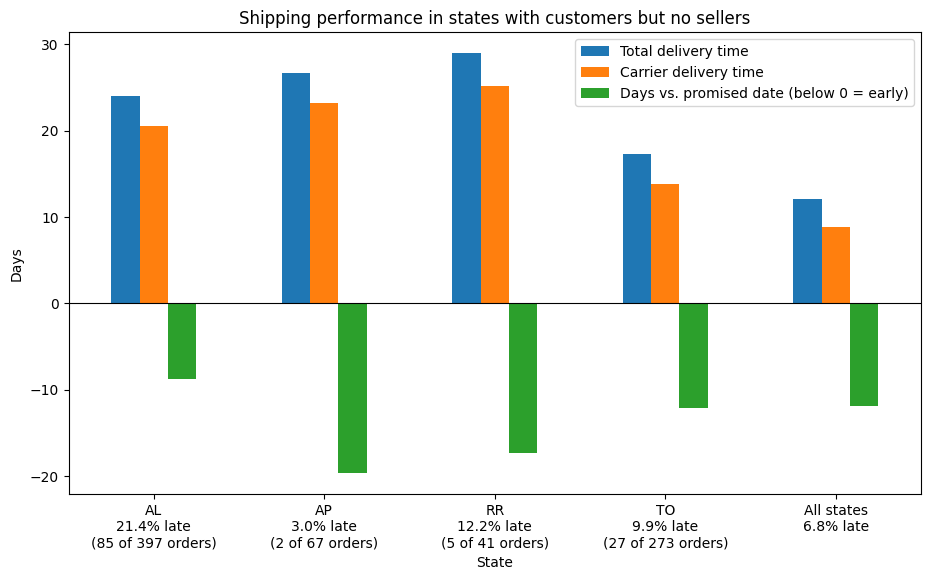

In [95]:
ax = chart01_df.plot(kind='bar', figsize=(11, 6))
ax.set_xticklabels(labels, rotation=0)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Shipping performance in states with customers but no sellers')
plt.xlabel('State')
plt.ylabel('Days')
plt.show()

##### 3. How do in-state vs. out-of-state deliveries compare in terms of timeliness and cost?

In [96]:
#since we need to compare the in state and out of state we need to have classification
full_geo_df['delivery_type'] = np.where(full_geo_df['seller_state'] == full_geo_df['customer_state'], 'In state', 'Out of state')

In [97]:
delivered_df = full_geo_df[full_geo_df['order_status'] == 'delivered'].copy()

In [98]:
delivered_df = delivered_df[delivered_df['customer_state'] != 'international']

In [99]:
delivered_df['order_id'].duplicated().sum()

np.int64(13665)

In [100]:
per_order_df = (delivered_df.groupby('order_id').agg(
    delivery_type = ('delivery_type', 'first'),
    customer_state = ('customer_state', 'first'),
    seller_state = ('seller_state', 'first'),
    delivery_days = ('delivery_days', 'first'),
    carrier_delivery_days = ('carrier_delivery_days', 'first'), 
    delay_days = ('delay_days', 'first'), 
    is_late = ('is_late', 'first'),
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum')  
).reset_index() )
per_order_df['freight_ratio'] = per_order_df['freight_value'] / per_order_df['price']

In [101]:
in_and_out_state_summary = (
    per_order_df.groupby('delivery_type').agg(
        avg_delivery_days = ('delivery_days', 'mean'), 
        avg_delay_days = ('delay_days', 'mean'),
        percntage_late_days = ('is_late', 'mean'),
        median_freight=('freight_value','median'),
        avg_freight_ratio=('freight_ratio','mean'),
        avg_carrier_days=('carrier_delivery_days','mean'),
        avg_freight = ('freight_value', 'mean')
    )
)
in_and_out_state_summary['percntage_late_days'] *= 100 
in_and_out_state_summary

,avg_delivery_days,avg_delay_days,percntage_late_days,median_freight,avg_freight_ratio,avg_carrier_days,avg_freight
delivery_type,,,,,,,
In state,7.486948,-10.325075,4.51028,12.69,0.238043,4.357877,15.447713
Out of state,14.692326,-12.733179,8.05027,19.04,0.347945,11.420244,26.901475


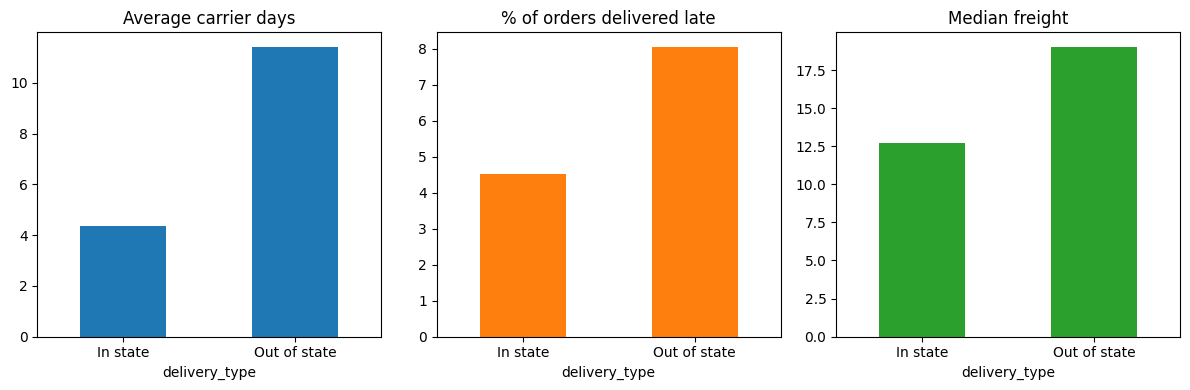

In [102]:
cols = ['avg_carrier_days', 'percntage_late_days', 'median_freight']
plot_df = in_and_out_state_summary.loc[['In state', 'Out of state'], cols]

plot_df.plot(kind='bar', subplots=True, layout=(1, 3), figsize=(12, 4), legend=False, rot=0,
             title=['Average carrier days', '% of orders delivered late', 'Median freight'])
plt.tight_layout()
plt.show()

##### 4. Which states or regions have the highest or lowest delivery performance?

In [103]:
# first we'll need to have a KPI as olist does not have one
region_performance = (per_order_df.groupby('seller_state').agg(
    avg_delivery_days = ('delivery_days', 'mean'),
    avg_carrier_delivery_days = ('carrier_delivery_days', 'mean'), 
    avg_delay_days = ('delay_days', 'mean'), 
    percntage_late_days = ('is_late', 'mean'),
    order_count = ('order_id', 'count')
))

region_performance['percntage_late_days'] *= 100

# I will round the results for better analysis
region_performance = region_performance.round({
    'avg_delivery_days': 2,
    'avg_carrier_delivery_days': 2,
    'avg_delay_days': 2,
    'percntage_late_days': 2
})

In [104]:
region_performance

,avg_delivery_days,avg_carrier_delivery_days,avg_delay_days,percntage_late_days,order_count
seller_state,,,,,
AM,47.33,44.00,9.00,33.333333,3
BA,13.46,10.02,-12.59,4.936015,547
CE,17.36,14.12,-13.19,7.058824,85
DF,12.01,9.08,-13.30,5.236908,802
ES,12.66,10.11,-13.06,6.168831,308
GO,12.41,9.88,-14.05,2.888889,450
MA,17.28,12.49,-11.27,19.060052,383
MG,12.42,9.20,-13.30,4.819435,7615
MS,11.94,7.70,-17.23,6.382979,47


- only the states with more than 100 order will be checked

In [105]:
# keep only states with at least 100 orders
region_performance_filtered = region_performance[region_performance['order_count'] >= 100].copy()
region_performance_filtered['percntage_late_days'] = region_performance_filtered['percntage_late_days'].astype(float)

In [106]:
national_late = per_order_df['is_late'].mean() * 100
all_states = region_performance_filtered.sort_values('percntage_late_days')

In [107]:
all_states

,avg_delivery_days,avg_carrier_delivery_days,avg_delay_days,percntage_late_days,order_count
seller_state,,,,,
GO,12.41,9.88,-14.05,2.888889,450
RS,11.07,7.64,-16.23,3.089598,1942
PE,12.40,10.22,-15.78,3.722084,403
MT,14.28,10.93,-15.63,3.731343,134
MG,12.42,9.20,-13.30,4.819435,7615
SC,13.29,10.25,-14.03,4.915254,3540
BA,13.46,10.02,-12.59,4.936015,547
DF,12.01,9.08,-13.30,5.236908,802
PR,12.98,9.49,-14.07,5.409416,7413


In [108]:
best5 = all_states.head(5)
worst5 = all_states.tail(5)

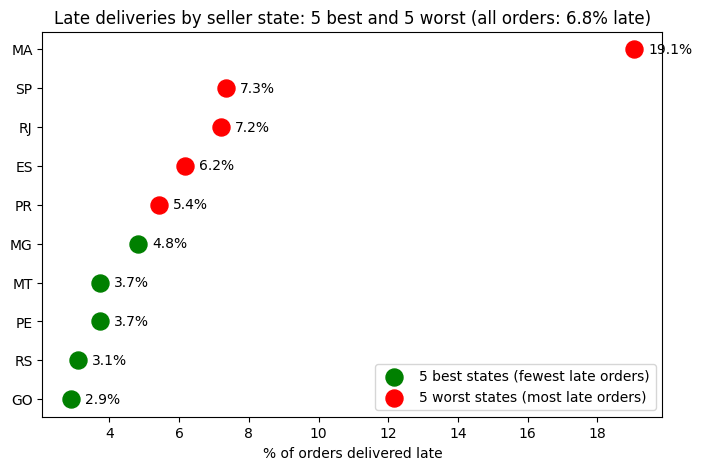

In [109]:
plt.figure(figsize=(8, 5))
plt.scatter(best5['percntage_late_days'], best5.index, s=150, color='green', label='5 best states (fewest late orders)')
plt.scatter(worst5['percntage_late_days'], worst5.index, s=150, color='red', label='5 worst states (most late orders)')
# write the % next to each dot
for state in best5.index:
    plt.text(best5.loc[state, 'percntage_late_days'] + 0.4, state, f"{best5.loc[state, 'percntage_late_days']:.1f}%", va='center')
for state in worst5.index:
    plt.text(worst5.loc[state, 'percntage_late_days'] + 0.4, state, f"{worst5.loc[state, 'percntage_late_days']:.1f}%", va='center')
plt.title(f'Late deliveries by seller state: 5 best and 5 worst (all orders: {national_late:.1f}% late)')
plt.xlabel('% of orders delivered late')
plt.legend()
plt.show()

##### 5. Does seller-customer distance correlate with higher freight or longer delivery times?

In [110]:
# to calculate the distance Iwill use this library 
!pip install geopy


[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [111]:
from geopy.distance import geodesic

In [112]:
full_geo_df.columns

Index(['order_id', 'order_item_id', 'seller_id', 'price', 'freight_value',
       'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_city', 'customer_state',
       'customer_state_name', 'delivery_days', 'carrier_delivery_days',
       'delay_days', 'is_late', 'seller_city', 'seller_state',
       'seller_state_name', 'customer_lat', 'customer_lng', 'seller_lat',
       'seller_lng', 'delivery_type'],
      dtype='object')

In [113]:
full_geo_df[['seller_lat', 'seller_lng', 'customer_lat', 'customer_lng']].isna().sum()

seller_lat      253
seller_lng      253
customer_lat    562
customer_lng    562
dtype: int64

- scince we have some null values and it is causing an issue for us, we'll drop them in a new dataframe

In [114]:
distance_df = full_geo_df.dropna(subset=['seller_lat','seller_lng','customer_lat','customer_lng']).copy()

In [115]:
distance_df = distance_df[['order_id', 'seller_id', 'customer_id', 'freight_value', 'delivery_days', 'seller_lat','seller_lng','customer_lat','customer_lng']].copy()

In [116]:
distance_df['distance_km'] = distance_df.apply(
    lambda row: geodesic(
        (row['seller_lat'], row['seller_lng']),
        (row['customer_lat'], row['customer_lng'])
    ).km,
    axis =1
)

In [117]:
my_corr = distance_df[['distance_km', 'freight_value', 'delivery_days']].corr()
my_corr

,distance_km,freight_value,delivery_days
distance_km,1.000000,0.389420,0.394373
freight_value,0.389420,1.000000,0.214832
delivery_days,0.394373,0.214832,1.000000


In [118]:
sample_df = distance_df.sample(1500, random_state=1)

In [119]:
corr_freight = distance_df['distance_km'].corr(distance_df['freight_value'])
corr_days = distance_df['distance_km'].corr(distance_df['delivery_days'])

In [120]:
freight_max = distance_df['freight_value'].quantile(0.99)
days_max = distance_df['delivery_days'].quantile(0.99)

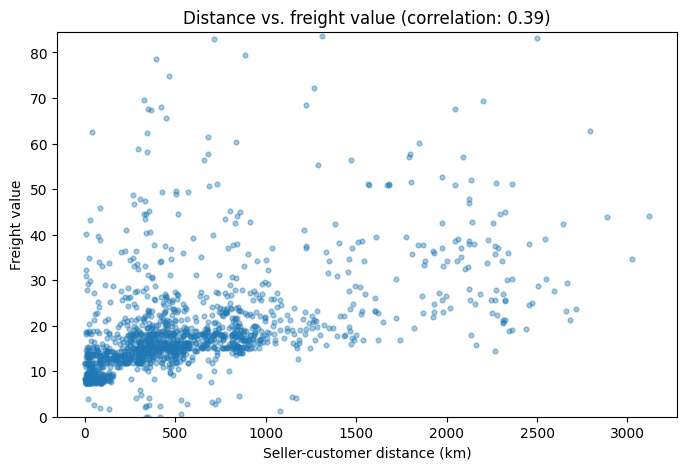

In [121]:
plt.figure(figsize=(8, 5))
plt.scatter(sample_df['distance_km'], sample_df['freight_value'], alpha=0.4, s=12)
plt.ylim(0, freight_max)
plt.title(f'Distance vs. freight value (correlation: {corr_freight:.2f})')
plt.xlabel('Seller-customer distance (km)')
plt.ylabel('Freight value')
plt.show()

In [122]:
distance_df['distance_group'] = 'Under 300 km'
distance_df.loc[distance_df['distance_km'] >= 300, 'distance_group'] = '300 - 1000 km'
distance_df.loc[distance_df['distance_km'] >= 1000, 'distance_group'] = 'Over 1000 km'
days_df = distance_df.dropna(subset=['delivery_days'])
distance_df['distance_group'].value_counts()

distance_group
300 - 1000 km    57625
Under 300 km     36581
Over 1000 km     17626
Name: count, dtype: int64

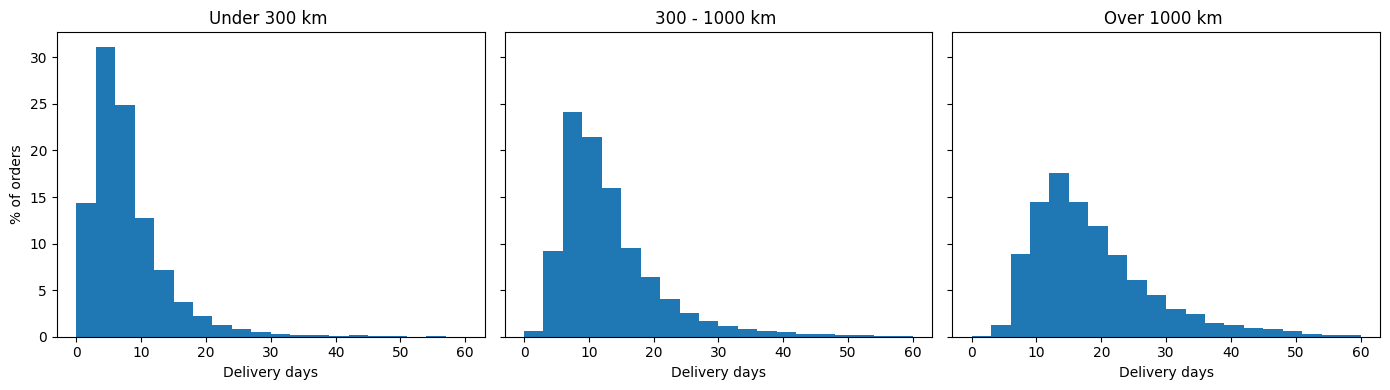

In [123]:
groups = ['Under 300 km', '300 - 1000 km', 'Over 1000 km']
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
for i in range(3):
    group_days = days_df[days_df['distance_group'] == groups[i]]['delivery_days']
    axes[i].hist(group_days, bins=range(0, 61, 3), weights=[100 / len(group_days)] * len(group_days))
    axes[i].set_title(f'{groups[i]} ')
    axes[i].set_xlabel('Delivery days')
axes[0].set_ylabel('% of orders')
plt.tight_layout()
plt.show()

### Part 5:

#### 1. Creating the tables that will be needed:

**Table One**

In [124]:
reviews_df = pd.read_csv('../Data_Cleaning/olist_order_reviews_dataset_cleaned.csv')

- The datasets has no clear `reason` column, so we will use the customers comment texts to get any clue about the issues

In [125]:
reviews_df['review_text'] = reviews_df['review_comment_title_english'].fillna('') + ' ' + reviews_df['review_comment_message_english'].fillna('')

In [126]:
#we turn it to lower cases so then when we search we get the triggered words
reviews_df['review_text'] = reviews_df['review_text'].str.lower()

In [127]:
#now we create our flagging columns:
reviews_df['damage_mention'] = reviews_df['review_text'].str.contains('damage|broken|defect|crack|torn', na=False)
reviews_df['delay_mention'] = reviews_df['review_text'].str.contains("late|delay|never arrived|not arrived|haven't arrived|hasn't arrived|not delivered | didn't receive | never received ", na=False)

In [128]:
#lastly we merge the reviews table we enhanced with the table we created in part 4, orders_customers_df
orders_reviews_df = pd.merge(orders_customers_df, reviews_df, left_on='order_id', right_on='order_id', how = 'left')

**Table Two**

some orders have more than one item so each will be in a seoerate row, to chnage that we are grouping so each order id will get just one row:

In [129]:
review_summary = reviews_df.groupby('order_id', as_index=False).agg({'review_score': 'min', 'damage_mention': 'max', 'delay_mention': 'max'})

In [130]:
#now we'll merge the full_info table (we need these informations for Q4 and Q5) with the review_summary
items_reviews_df = pd.merge(full_info_df, review_summary, left_on='order_id', right_on='order_id', how='left')

In [131]:
products_df = pd.read_csv('../Data_Cleaning/olist_products_dataset_cleaned.csv')

In [132]:
# we need the product category for Q5
products_df_part = products_df[['product_id', 'product_category_name']]

In [133]:
reviews_table02 = pd.merge(items_reviews_df, products_df_part, left_on='product_id', right_on='product_id', how='left')

In [134]:
#to get the english translation
cat_name = pd.read_csv('../Data_Cleaning/product_category_name_translation.csv')

In [135]:
reviews_table02['product_category_name'].isin(cat_name['product_category_name_english']).sum()

np.int64(7633)

In [136]:
len(reviews_table02) 

112646

- as it is shown above there is a diffrance in numbers, because not all product categories have their name translated. therefore we'll be using `products` table alongside the `category translated` table 

In [137]:
reviews_table02 = pd.merge(reviews_table02, cat_name, left_on='product_category_name', right_on='product_category_name', how='left')

In [138]:
#this is how we'll solve the issue
reviews_table02['product_category_name_english'] = reviews_table02['product_category_name_english'].fillna(reviews_table02['product_category_name'])

In [139]:
reviews_table02['product_category_name_english'].isnull().sum()

np.int64(0)

 Now we want to keep only the delivered orders: 

In [140]:
delivered_items = reviews_table02[reviews_table02['order_status'] == 'delivered'].copy()

In [141]:
delivered_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'customer_unique_id',
       'customer_zip_code_prefix', 'customer_city', 'customer_state',
       'state_name', 'delivery_days', 'carrier_delivery_days', 'delay_days',
       'is_late', 'seller_zip_code_prefix', 'seller_city', 'seller_state',
       'seller_state_name', 'review_score', 'damage_mention', 'delay_mention',
       'product_category_name', 'product_category_name_english'],
      dtype='object')

In [142]:
delivered_items['delay_mention'].dtype

dtype('O')

In [143]:
# to make the data type boolean
delivered_items['damage_mention'] = delivered_items['damage_mention'] == True
delivered_items['delay_mention'] = delivered_items['delay_mention'] == True

In [144]:
delivered_items['damage_mention'].dtype

dtype('bool')

- Now this is very important as we'll split the **seller's part** and the **carrier's part**

In [145]:
delivered_items['shipping_limit_date'].dtypes

dtype('O')

In [146]:
delivered_items['shipping_limit_date'] = pd.to_datetime(delivered_items['shipping_limit_date'])

In [147]:
#to find how much did the order stay with the seller 
delivered_items['seller_handling_days'] = (delivered_items['order_delivered_carrier_date'] - delivered_items['order_purchase_timestamp']).dt.days

In [148]:
#this will show true if the seller was late in handing the order
delivered_items['seller_late_handoff'] = delivered_items['order_delivered_carrier_date'] > delivered_items['shipping_limit_date']

In [149]:
# a column to track all orders with any delivery issue
delivered_items['delivery_issue'] = delivered_items['is_late'] | delivered_items['delay_mention'] | delivered_items['damage_mention']

- To have one row per order and seller. As an order with several items would otherwise be counted several times: 

In [150]:
delivered_items.duplicated(['seller_id', 'order_id']).sum()

np.int64(12357)

In [151]:
seller_orders = delivered_items.groupby(['seller_id', 'order_id']).agg(
    seller_state = ('seller_state', 'first'),
    is_late = ('is_late', 'first'),
    seller_late_handoff = ('seller_late_handoff', 'max'),
    seller_handling_days = ('seller_handling_days', 'first'),
    carrier_delivery_days = ('carrier_delivery_days', 'first'),
    damage_mention = ('damage_mention', 'max'),
    delivery_issue = ('delivery_issue', 'max')
).reset_index()

In [152]:
seller_orders.duplicated(['seller_id', 'order_id']).sum()

np.int64(0)

#### 2. Answering the Questions:

##### 1. How does delivery performance affect customer satisfaction and reviews?

- we want to have the orders that got delivered and also have a review scorw the asses the performance: 

In [153]:
needed_cols = ['order_id', 'review_score', 'delivery_days', 'delay_days', 'is_late']
delivered_score = orders_reviews_df[ (orders_reviews_df['order_status'] == 'delivered')& (orders_reviews_df['review_score'].notnull())][needed_cols].copy()

In [154]:
#check how the satisfactions differs between late and not late orders
delivered_score.groupby('is_late')[['review_score']].mean()

,review_score
is_late,
False,4.290200
True,2.270528


In [155]:
#classifying how late an order is
delivered_score['delay_explanation'] = 'Early more than a week'
delivered_score.loc[delivered_score['delay_days'] > -8, 'delay_explanation'] = 'Early 0-7 days'
delivered_score.loc[delivered_score['delay_days'] > 0, 'delay_explanation'] = 'Late 1-3 days'
delivered_score.loc[delivered_score['delay_days'] > 3, 'delay_explanation'] = 'Late 4-7 days'
delivered_score.loc[delivered_score['delay_days'] > 7, 'delay_explanation'] = 'Late more than a week'

In [156]:
#classify what is a low score for us
delivered_score['low_score'] = delivered_score['review_score'] <=2

In [157]:
delay_summary = delivered_score.groupby('delay_explanation').agg(
    avg_review_score = ('review_score', 'mean'),
    low_score_pct = ('low_score', 'mean'), 
    reviews_count = ('review_score', 'count') )
delay_summary['low_score_pct'] *= 100

In [158]:
#checking the table insights 
delay_summary

,avg_review_score,low_score_pct,reviews_count
delay_explanation,,,
Early 0-7 days,4.188301,10.413303,18582
Early more than a week,4.316808,8.975170,71163
Late 1-3 days,3.289488,32.183288,1855
Late 4-7 days,2.103193,67.673888,1754
Late more than a week,1.699678,79.191991,2797


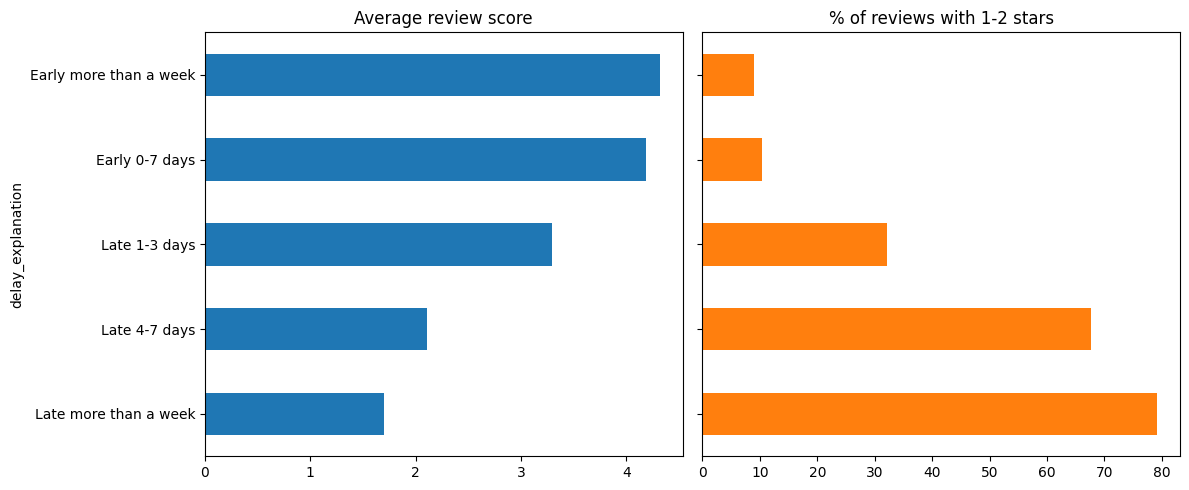

In [159]:
y_order = ['Late more than a week', 'Late 4-7 days', 'Late 1-3 days', 'Early 0-7 days', 'Early more than a week']
delay_plot_df = delay_summary.loc[y_order, ['avg_review_score', 'low_score_pct']]
delay_plot_df.plot(kind='barh', subplots=True, layout=(1, 2), figsize=(12, 5) ,legend=False, sharex=False, sharey=True, title=['Average review score', '% of reviews with 1-2 stars'])
plt.tight_layout()

plt.show()

In [160]:
delivered_score[['delivery_days', 'delay_days', 'review_score']].corr()

,delivery_days,delay_days,review_score
delivery_days,1.000000,0.602374,-0.334118
delay_days,0.602374,1.000000,-0.267810
review_score,-0.334118,-0.267810,1.000000


##### 2. What percentage of order cancellations are due to shipping problems?

In [161]:
# we need to first get the canceled orders 
canceled = orders_reviews_df[orders_reviews_df['order_status'] == 'canceled'].copy()

In [162]:
canceled['damage_mention'].dtype

dtype('O')

In [163]:
# orders without a review have empty flags so they become False
canceled['damage_mention'] = canceled['damage_mention'] == True
canceled['delay_mention'] = canceled['delay_mention'] == True

In [164]:
canceled['damage_mention'].dtype

dtype('bool')

In [165]:
# we want to make sure that each order is counted once only 
canceled_orders = canceled.groupby('order_id'). agg({'order_delivered_carrier_date': 'first', 'delay_mention': 'max', 'damage_mention': 'max'})

In [166]:
#now we'll make our criterias 
canceled_orders['carrier_received'] = canceled_orders['order_delivered_carrier_date'].notnull()
canceled_orders['complaint'] = canceled_orders['delay_mention'] | canceled_orders['damage_mention']
canceled_orders['shipping_issues'] = canceled_orders['carrier_received'] & canceled_orders['complaint']

In [167]:
canceled_pct = canceled_orders[['carrier_received', 'complaint' , 'shipping_issues']].mean() * 100
canceled_pct

carrier_received    12.00
complaint           12.80
shipping_issues      1.28
dtype: float64

- Only about 12% of canceled orders had reached the carrier so most cancellations happened before shipping

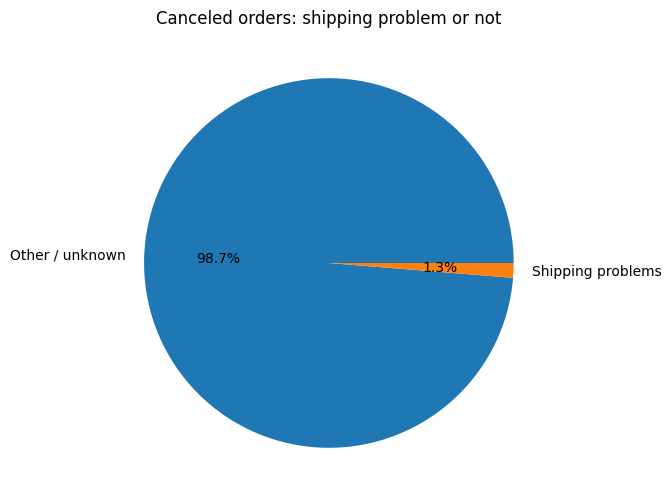

In [168]:
canceled_orders['shipping_issues'].map({True: 'Shipping problems', False: 'Other / unknown'}).value_counts().plot(kind='pie', autopct='%1.1f%%', figsize=(6, 6), title='Canceled orders: shipping problem or not')
plt.ylabel('')
plt.show()

##### 3. How many cancellations or complaints relate to late or damaged deliveries?

**Part 1: complaints relate to late or damaged deliveries:**

In [169]:
#for the coplaints we only have the comments to rely on so we'll get the orders that have a review:
reviews_df['has_comment'] = reviews_df['review_text'].str.strip() != ''
reviews_df['has_comment'].sum()

np.int64(42686)

In [170]:
#then we neet to classify each review  
reviews_df['reviews_type'] = 'No delay/ damage mentioned'
reviews_df.loc[reviews_df['delay_mention'], 'reviews_type'] = 'Delay only'
reviews_df.loc[reviews_df['damage_mention'], 'reviews_type'] = 'Damaged only'
reviews_df.loc[reviews_df['damage_mention'] & reviews_df['delay_mention'], 'reviews_type'] = 'Both late and damaged'

In [171]:
complaint_reviews_count = reviews_df['reviews_type'].value_counts()
complaint_reviews_count

reviews_type
No delay/ damage mentioned    95666
Delay only                     2501
Damaged only                   1021
Both late and damaged            36
Name: count, dtype: int64

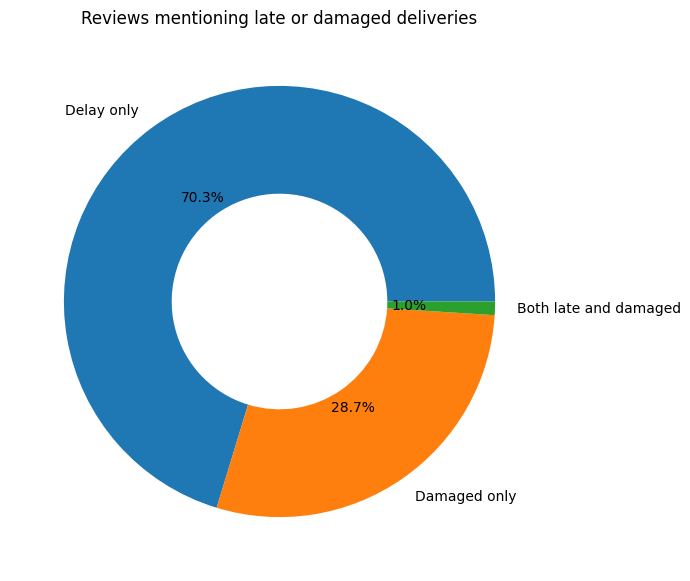

In [172]:
#we just want to check the onees with delay or damages mentioned
complaint_only = complaint_reviews_count.drop('No delay/ damage mentioned')
comments_total = reviews_df['has_comment'].sum()
complaint_only.plot(kind='pie', autopct='%1.1f%%' , figsize=(7, 7), wedgeprops={'width': 0.5}, title='Reviews mentioning late or damaged deliveries')
plt.ylabel('')
plt.show()

**Part 2: cancelation relate to late or damaged deliveries:**

In [173]:
# I'll use the canceled from question 2
canceled_orders['cancel_type'] = 'No delay/ damage mentioned'
canceled_orders.loc[canceled_orders['delay_mention'], 'cancel_type'] = 'Delay only'
canceled_orders.loc[canceled_orders['damage_mention'], 'cancel_type'] = 'Damaged only'
canceled_orders.loc[canceled_orders['delay_mention'] & canceled_orders['damage_mention'], 'cancel_type'] = 'Both late and damaged'

In [174]:
cancel_type_counts = canceled_orders['cancel_type'].value_counts()
cancel_type_counts

cancel_type
No delay/ damage mentioned    545
Delay only                     64
Damaged only                   15
Both late and damaged           1
Name: count, dtype: int64

In [175]:
cancel_only = cancel_type_counts.drop('No delay/ damage mentioned')
canceled_total = len(canceled_orders)

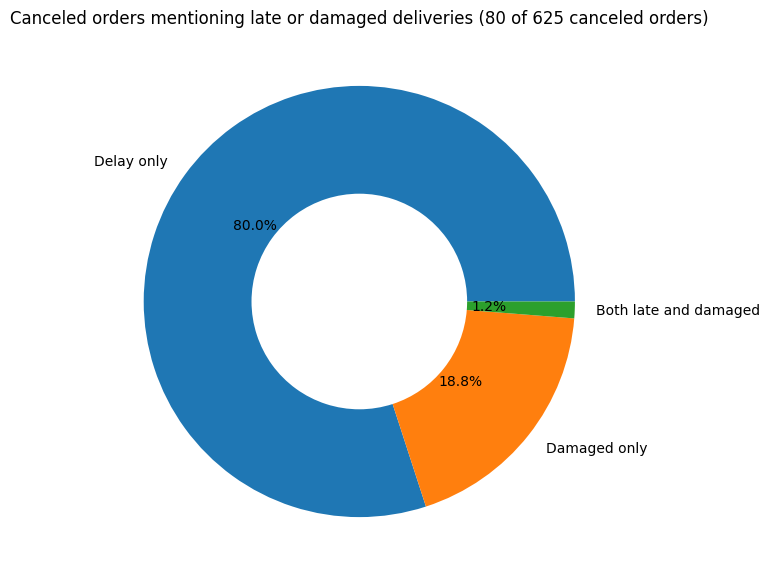

In [176]:
cancel_only.plot(kind='pie', autopct='%1.1f%%', figsize=(7, 7), wedgeprops={'width': 0.5}, title=f'Canceled orders mentioning late or damaged deliveries ({cancel_only.sum()} of {canceled_total} canceled orders)')
plt.ylabel('')
plt.show()

##### 4. Are there specific sellers with repeated delivery issues (suggesting seller-related problems)?

In [177]:
# we want to check per seller
seller_summary = seller_orders.groupby('seller_id').agg(
    seller_state = ('seller_state', 'first'),
    orders = ('order_id', 'count'),
    issue_orders = ('delivery_issue', 'sum'),
    issue_pct = ('delivery_issue', 'mean')
)
seller_summary['issue_pct'] *= 100

In [178]:
seller_summary.head(2)

,seller_state,orders,issue_orders,issue_pct
seller_id,,,,
0015a82c2db000af6aaaf3ae2ecb0532,SP,3,0,0.000000
001cca7ae9ae17fb1caed9dfb1094831,ES,195,26,13.333333


In [179]:
# we will filter out any seller with less than 30 orders
seller_filtered = seller_summary[seller_summary['orders'] >= 30]
overall_issue_pct = seller_orders['delivery_issue'].mean() * 100

In [180]:
top_sellers = seller_filtered.sort_values('issue_pct', ascending=False).head(10) #to top 10 sellers with issues
top_sellers

,seller_state,orders,issue_orders,issue_pct
seller_id,,,,
ad781527c93d00d89a11eecd9dcad7c1,SP,38,14,36.842105
2a1348e9addc1af5aaa619b1a3679d6b,MG,48,16,33.333333
54965bbe3e4f07ae045b90b0b8541f52,PR,73,24,32.876712
ede0c03645598cdfc63ca8237acbe73d,SP,43,14,32.558140
835f0f7810c76831d6c7d24c7a646d4d,SP,42,12,28.571429
beadbee30901a7f61d031b6b686095ad,SP,64,16,25.000000
712e6ed8aa4aa1fa65dab41fed5737e4,SC,77,19,24.675325
a49928bcdf77c55c6d6e05e09a9b4ca5,SP,96,23,23.958333
ec8879960bd2221d5c32f8e12f7da711,SP,35,8,22.857143


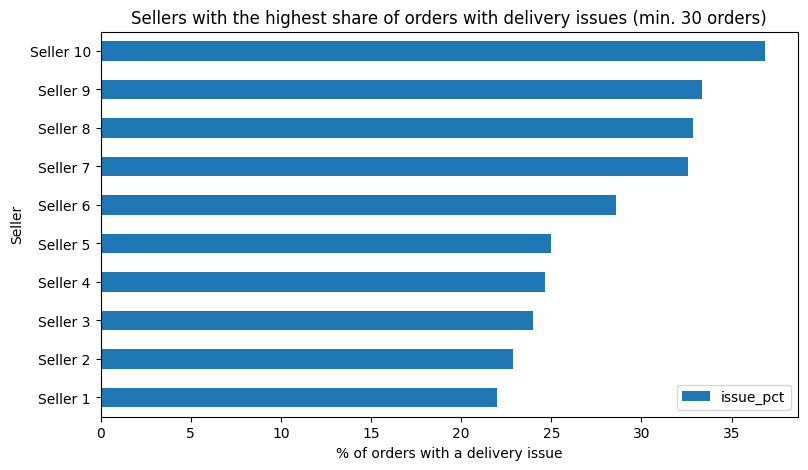

In [181]:
top_sellers = top_sellers.sort_values('issue_pct', ascending=True)
top_sellers['seller_label'] = [
    f'Seller {i}' for i in range(1, len(top_sellers) + 1)
]

top_sellers.plot( x='seller_label', y='issue_pct', kind='barh', figsize=(9, 5))

plt.title('Sellers with the highest share of orders with delivery issues (min. 30 orders)')
plt.xlabel('% of orders with a delivery issue')
plt.ylabel('Seller')
plt.show()

In [182]:
top_sellers

,seller_state,orders,issue_orders,issue_pct,seller_label
seller_id,,,,,
0b35c634521043bf4b47e21547b99ab5,PR,50,11,22.000000,Seller 1
ec8879960bd2221d5c32f8e12f7da711,SP,35,8,22.857143,Seller 2
a49928bcdf77c55c6d6e05e09a9b4ca5,SP,96,23,23.958333,Seller 3
712e6ed8aa4aa1fa65dab41fed5737e4,SC,77,19,24.675325,Seller 4
beadbee30901a7f61d031b6b686095ad,SP,64,16,25.000000,Seller 5
835f0f7810c76831d6c7d24c7a646d4d,SP,42,12,28.571429,Seller 6
ede0c03645598cdfc63ca8237acbe73d,SP,43,14,32.558140,Seller 7
54965bbe3e4f07ae045b90b0b8541f52,PR,73,24,32.876712,Seller 8
2a1348e9addc1af5aaa619b1a3679d6b,MG,48,16,33.333333,Seller 9


##### 5. Are broken or delayed items concentrated with certain sellers, products, or categories (shipping vs. seller responsibility)?

**Part 1: Who is responsible for delays?**

In [185]:
late_orders = seller_orders[seller_orders['is_late'] == True]

In [189]:
# average days at each stage to check for on-time vs. late orders
stage_time = seller_orders.groupby('is_late')[['seller_handling_days', 'carrier_delivery_days']].mean()
stage_time.index = ['On time', 'Late']
stage_time

,seller_handling_days,carrier_delivery_days
On time,2.523980,7.518455
Late,5.587408,27.380654


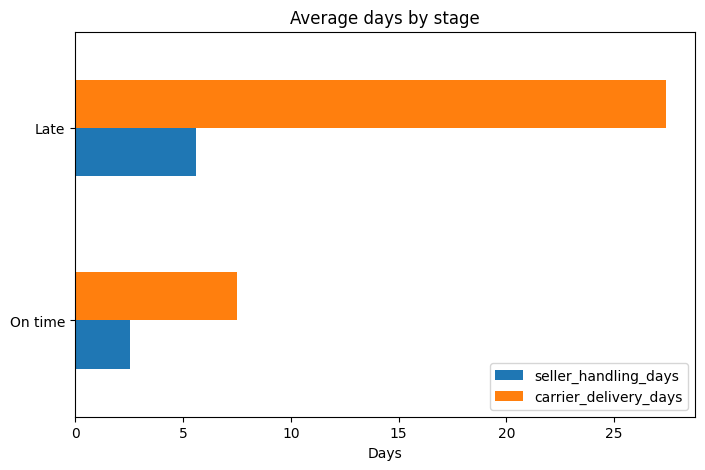

In [190]:
stage_time.plot(kind='barh', figsize=(8, 5), title='Average days by stage')
plt.xlabel('Days')
plt.show()

## Q: How well is Olist’s shipping partner performing in terms of timeliness, cost, reliability, and service quality?

In [192]:
orders =pd.read_csv("../Data_Cleaning/olist_orders_dataset_cleaned.csv")

In [193]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [194]:
orders[["order_delivered_customer_date","order_estimated_delivery_date"]].isnull().sum()

order_delivered_customer_date    2956
order_estimated_delivery_date       0
dtype: int64

In [195]:
orders.shape
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99229 entries, 0 to 99228
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99229 non-null  object
 1   customer_id                    99229 non-null  object
 2   order_status                   99229 non-null  object
 3   order_purchase_timestamp       99229 non-null  object
 4   order_approved_at              99083 non-null  object
 5   order_delivered_carrier_date   97448 non-null  object
 6   order_delivered_customer_date  96273 non-null  object
 7   order_estimated_delivery_date  99229 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [196]:
## Explore the order status

In [197]:
orders["order_status"].value_counts()

order_status
delivered      96267
shipped         1106
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [198]:
## filter the data (delivered) only 

In [199]:
delivered = orders[orders["order_status"] == "delivered"].copy()

In [200]:
delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [201]:
orders.dtypes

order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

In [202]:
# so , we need to amke the type datetime

In [203]:
orders['order_purchase_timestamp']= pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_approved_at']= pd.to_datetime(orders['order_approved_at'])
orders['order_delivered_carrier_date']= pd.to_datetime(orders['order_delivered_carrier_date'])
orders['order_delivered_customer_date']= pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date']= pd.to_datetime(orders['order_estimated_delivery_date'])

In [204]:
delivered = orders[orders["order_status"] == "delivered"].copy()
# check again :
print(delivered["order_delivered_customer_date"].isna().sum()) 

0


#### 1- Time

In [205]:
# calculate the diffrent :
delivered["delivery_days"] = (delivered["order_delivered_customer_date"]- delivered["order_purchase_timestamp"]).dt.days

In [206]:
delivered["delivery_days"].mean()

np.float64(12.103109061256713)

In [207]:
delivered.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2


In [208]:
# dt.normalize() , if there is same date but different time , order_estimated_delivery_date there no hours !
delivered["status"]= np.where(delivered["order_delivered_customer_date"].dt.normalize() > delivered["order_estimated_delivery_date"].dt.normalize(),"Delay","On Time")

In [209]:
print(delivered["status"].value_counts())

#count the percentage :
print(delivered["status"].value_counts(normalize=True) * 100)

status
On Time    89736
Delay       6531
Name: count, dtype: int64
status
On Time    93.215744
Delay       6.784256
Name: proportion, dtype: float64


In [210]:
# by these percentage , plot a bar chart :

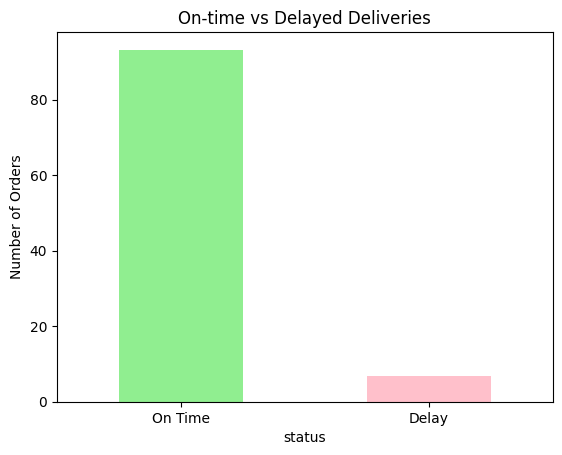

In [211]:
(delivered["status"].value_counts(normalize=True) * 100).plot(kind="bar", color=["lightgreen", "pink"])
plt.title("On-time vs Delayed Deliveries")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.show()

In [212]:
# calc the diffrence between dilvered customer date , and estimated date 

In [213]:
delivered["delivery_difference"]  =(delivered["order_delivered_customer_date"].dt.normalize()
   - delivered["order_estimated_delivery_date"].dt.normalize()).dt.days

In [214]:
# if it with minus then its on time , otherwise it is delay

In [215]:
delivered["delivery_difference"].describe()

count    96267.000000
mean       -11.865364
std         10.180969
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_difference, dtype: float64

In [216]:
# because most of the delivery on time

In [217]:
#the max is 188 !!!
extreme_delay= delivered[delivered["delivery_difference"] > 100]

print("Number of orders:", len(extreme_delay))
print("Percentage:",round(len(extreme_delay) / len(delivered) * 100, 2))

Number of orders: 39
Percentage: 0.04


In [218]:
# filter , only the delay 
delay_days = delivered[delivered["delivery_difference"] > 0]["delivery_difference"]

In [219]:
delay_days.describe()

count    6531.000000
mean       10.623029
std        14.647611
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_difference, dtype: float64

In [220]:
# median : 7 days , 75% of tha data : 13 days , mean: 10.6 days 

#### 2- cost 

use olist_order_items_dataset to take the 

In [223]:
item=pd.read_csv("../Data_Cleaning/olist_order_items_dataset_cleaned.csv")

In [224]:
item.head()

,Unnamed: 0,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [225]:
# we need , to count the ratio:
item[["price", "freight_value"]].head()

,price,freight_value
0,58.90,13.29
1,239.90,19.93
2,199.00,17.87
3,12.99,12.79
4,199.90,18.14


In [226]:
#extra

In [227]:
item = item.drop(columns=["Unnamed: 0"])

In [228]:
# calc the ratio 

In [229]:
item["freight_ratio"] = item["freight_value"] / item["price"]

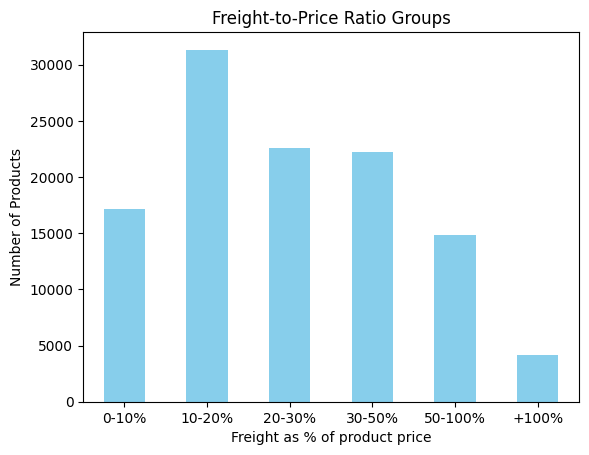

In [230]:
item["ratio_group"]= pd.cut(item["freight_ratio"],bins=[0, 0.1, 0.2, 0.3, 0.5, 1, float("inf")],labels=["0-10%", "10-20%", "20-30%", "30-50%", "50-100%", "+100%"])

groups=(item["ratio_group"].value_counts().sort_index()).plot(kind="bar",color="skyblue")
plt.title("Freight-to-Price Ratio Groups")
plt.xlabel("Freight as % of product price")
plt.ylabel("Number of Products")
plt.xticks(rotation=0)
plt.show()

In [231]:
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

In [232]:
item["freight_value"].mean()

np.float64(19.989678284182304)

In [233]:
## mean is 32% of item price , Shipping typically costs about 23% of the product price (median), while the average is 32% because a few low-priced
#items have very high shipping costs

In [234]:
# Free delivery :
print((item["freight_value"]==0).mean()* 100)

0.34000319585249367


In [235]:
# to find the price for free delivery :
free = item[item["freight_value"] == 0]
print(free["price"].describe())

count    383.000000
mean      98.601488
std       50.004247
min       53.900000
25%       69.900000
50%       99.900000
75%      106.900000
max      712.900000
Name: price, dtype: float64


#### 3- Reliability 

In [236]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [237]:
# order_status column
orders["order_status"].value_counts(normalize=True)*100

order_status
delivered      97.014986
shipped         1.114594
canceled        0.629856
unavailable     0.613732
invoiced        0.316440
processing      0.303339
created         0.005039
approved        0.002016
Name: proportion, dtype: float64

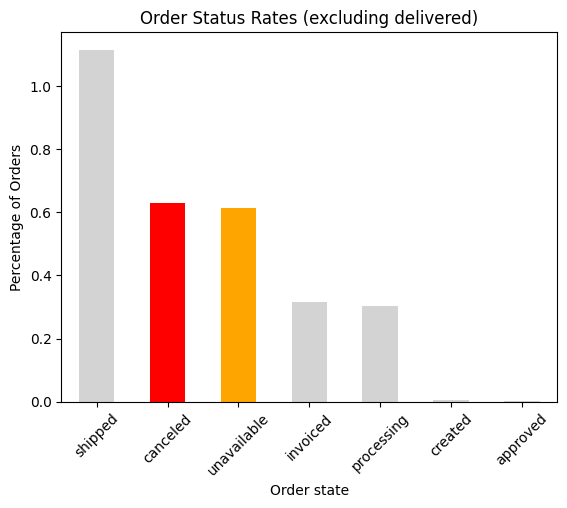

In [238]:
(orders["order_status"].value_counts(normalize=True) * 100).drop("delivered").plot(kind="bar", color= ["lightgray", "red", "orange", "lightgray", "lightgray", "lightgray", "lightgray"])
plt.title("Order Status Rates (excluding delivered)")
plt.ylabel("Percentage of Orders")
plt.xlabel("Order state")
plt.xticks(rotation=45)


plt.show()

In [239]:
## Reliability is high: 1.24% of orders were canceled or unavailable, and only 0.36% of delivered orders arrived more than 30 days late.

In [240]:
# more than one month :
severe = delivered["delivery_difference"] > 30
print(severe.sum())
print(severe.mean() * 100)

345
0.358378260463087


### Reviewd

In [242]:
review=pd.read_csv("../Data_Cleaning/olist_order_reviews_dataset_cleaned.csv")

In [243]:
review.head()

,review_id,order_id,review_score,review_comment_title,review_comment_title_english,review_comment_message,review_comment_message_english,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,NaN,Recebi bem antes do prazo estipulado.,I received it well before the stipulated time.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,NaN,Parabéns lojas lannister adorei comprar pela I...,Congratulations Lannister stores I loved shopp...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [244]:
review["review_score"].describe()

count    99224.000000
mean         4.086421
std          1.347579
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          5.000000
Name: review_score, dtype: float64

In [245]:
# for more than review each order :
print(len(review) - review["order_id"].nunique())  

551


In [246]:
#so we clean the review to see if there is any diffrent :
clean_review= review.drop_duplicates(subset="order_id", keep="last")
print((clean_review["review_score"].value_counts(normalize=True).sort_index() * 100).round(2))

review_score
1    11.51
2     3.17
3     8.24
4    19.30
5    57.78
Name: proportion, dtype: float64


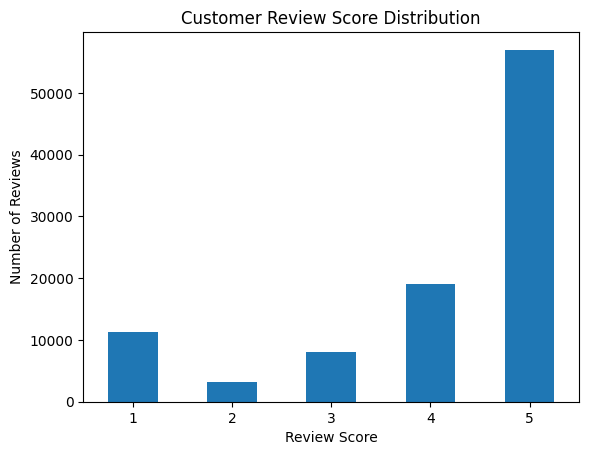

In [247]:
clean_review["review_score"].value_counts().sort_index().plot( kind="bar")

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)

plt.show()

In [248]:
low= review[review["review_score"]>= 4]
print(low["review_comment_message_english"].dropna().head(20))

3        I received it well before the stipulated time.
4     Congratulations Lannister stores I loved shopp...
9     efficient device. on the website the brand of ...
12    But a little slowing down...for the price it's...
15    Reliable seller, ok product and delivery on time.
22                                        store note 10
24                 thanks for the attention given to me
27    The purchase was made easily.\r\nDelivery was ...
28                           very nice and cheap watch.
34    I received exactly what I expected. Other orde...
36                                        I recommend ,
37                                            very good
38    I'm completely in love, super responsible and ...
43                            Very good. very fragrant.
47    great seller arrived before the deadline, I lo...
49               Smooth and efficient purchase process.
50                  I hope it lasts because it's furry.
55                                              

# Q3 

In [250]:
customers=pd.read_csv("../Data_Cleaning/olist_customers_dataset_cleaned.csv")

In [251]:
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,state_name
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP,Sao Paulo
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP,Sao Paulo
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP,Sao Paulo
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP,Sao Paulo
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP,Sao Paulo


In [253]:
#### sellers for each order :
sellers = pd.read_csv("../Data_Cleaning/olist_sellers_dataset_cleaned.csv")
print(sellers["seller_state_name"].value_counts().head(10))

seller_state_name
Sao Paulo            1849
Parana                349
Minas Gerais          244
Santa Catarina        190
Rio de Janeiro        171
Rio Grande do Sul     129
Goias                  40
Federal District       30
Espirito Santo         23
Bahia                  19
Name: count, dtype: int64


In [254]:
state_d=delivered.merge(customers[["customer_id", "customer_state", "state_name"]],on="customer_id", how="left")


In [255]:
state_d["is_late"] = state_d["status"] == "Delay" 


In [256]:
items_sellers = item.merge(sellers[["seller_id", "seller_state"]], on="seller_id", how="left")
order_seller = items_sellers.drop_duplicates(subset="order_id", keep="first")[["order_id", "seller_state"]]

In [257]:
#amother merge :
state_d = state_d.merge(order_seller, on="order_id", how="left")

In [258]:
item_state= item.merge(state_d[["order_id", "state_name"]],  on="order_id",how="left")

item_state.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,freight_ratio,ratio_group,state_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,0.225637,20-30%,Rio de Janeiro
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,0.083076,0-10%,Sao Paulo
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,0.089799,0-10%,Minas Gerais
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,0.984604,50-100%,Sao Paulo
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,0.090745,0-10%,Sao Paulo


## Q4 
Is the shipping partner meeting expectations for on-time delivery and fair pricing?

In [259]:
# we solved from Q2 , on time delivery  , based on set 3 Q 2, 3 , 4 also

In [260]:
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

In [261]:
high_shipping=item[item["freight_ratio"]>1]

In [262]:
high_shipping.describe()

,order_item_id,price,freight_value,freight_ratio
count,4124.000000,4124.000000,4124.000000,4124.000000
mean,1.433075,17.623378,24.332825,1.514666
std,1.216601,15.994419,22.651010,0.914294
min,1.000000,0.850000,7.390000,1.000500
25%,1.000000,10.500000,15.100000,1.111429
50%,1.000000,13.900000,18.230000,1.279000
75%,1.000000,18.900000,25.630000,1.611395
max,20.000000,189.900000,299.160000,26.235294


# Set 3 
## Q1: -What is the average freight value, and what percentage of the total product price does it represent?

In [263]:
# take the average for freight value
item["freight_value"].describe()

count    112646.000000
mean         19.989678
std          15.805705
min           0.000000
25%          13.080000
50%          16.260000
75%          21.150000
max         409.680000
Name: freight_value, dtype: float64

In [264]:
#  percentage of the total product price 
total_freight = item["freight_value"].sum()
total_product_price = item["price"].sum()

In [265]:
# percentage :
print(total_freight/ total_product_price * 100)

16.567640140594843


In [266]:
#Ratio
item["freight_ratio"].describe()

count    112646.000000
mean          0.320860
std           0.349897
min           0.000000
25%           0.134031
50%           0.231356
75%           0.393036
max          26.235294
Name: freight_ratio, dtype: float64

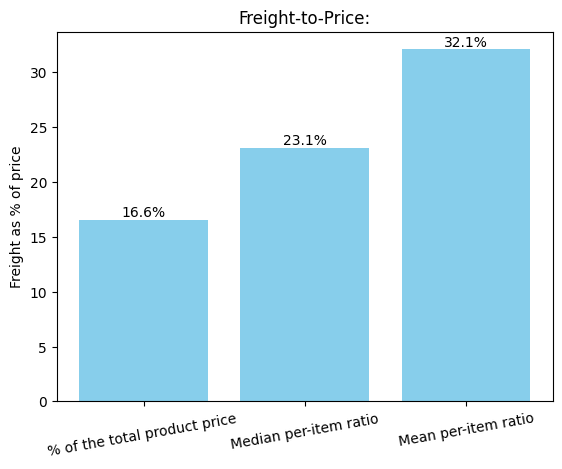

In [267]:
#Create data frame to make plot
vals = {
    "% of the total product price ": total_freight / total_product_price * 100,
    "Median per-item ratio": item["freight_ratio"].median() * 100,
    "Mean per-item ratio": item["freight_ratio"].mean() * 100,}
#plot
Graph = plt.bar(vals.keys(), vals.values(), color="skyblue")
plt.bar_label(Graph, fmt="%.1f%%")
plt.ylabel("Freight as % of price")
plt.xticks(rotation=10)

plt.title("Freight-to-Price:")
plt.show()

##### On average, freight is 19.99 BRL per item, equal to 16.6% of total product value. The median item pays 23% of its price, while the mean is higher (32%) because low-priced items carry proportionally heavy freight.

## Q2
### -How does the freight-to-price ratio vary by product category or state?

In [269]:
products= pd.read_csv("../Data_Cleaning/olist_products_dataset_cleaned.csv") 

In [270]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### By product category 

In [271]:
# merge step: item with products data by id

In [272]:
item_category = item.merge(products[["product_id", "product_category_name"]],on="product_id",how="left")

In [274]:
# make the names of the categories in English
tran=pd.read_csv("../Data_Cleaning/product_category_name_translation.csv")

In [275]:
item_category=item_category.merge(tran[["product_category_name", "product_category_name_english"]], on="product_category_name", how="left" )

In [276]:
print(item_category[["price", "freight_value", "freight_ratio"]].head())

    price  freight_value  freight_ratio
0   58.90          13.29       0.225637
1  239.90          19.93       0.083076
2  199.00          17.87       0.089799
3   12.99          12.79       0.984604
4  199.90          18.14       0.090745


In [277]:
# for each category 
category_ratio = (item_category.groupby("product_category_name")["freight_ratio"].mean()* 100)
category_ratio = category_ratio.sort_values(ascending=False)
print(category_ratio)

product_category_name
casa_conforto_2                   93.386243
dvds_blu_ray                      83.304467
eletronicos                       68.351661
artigos_de_natal                  67.565952
fashion_underwear_e_moda_praia    56.550343
                                    ...    
relogios_presentes                17.058094
portateis_casa_forno_e_cafe       16.434979
seguros_e_servicos                14.754843
pc_gamer                           9.655630
pcs                                5.661292
Name: freight_ratio, Length: 74, dtype: float64


In [278]:
# another way by mean value/mean price
cat = item_category.groupby("product_category_name_english").agg(items=("order_id", "count"),freight=("freight_value", "sum"),price=("price", "sum")
 ,freight_mean =("freight_value", "median"),price_mean =("price", "median"))
cat["freight_ratio"] = (cat["freight"] / cat["price"]).round(3)*100
cat.sort_values(by="freight_ratio", ascending=False)

,items,freight,price,freight_mean,price_mean,freight_ratio
product_category_name_english,,,,,,
home_comfort_2,30,410.31,760.27,15.10,12.900,54.0
flowers,33,488.87,1110.04,16.11,25.990,44.0
furniture_mattress_and_upholstery,38,1630.46,4368.08,38.97,85.000,37.3
christmas_supplies,153,3229.30,8800.82,17.92,44.900,36.7
diapers_and_hygiene,39,573.68,1567.59,12.92,37.000,36.6
...,...,...,...,...,...,...
watches_gifts,5991,100535.93,1205005.68,15.82,129.000,8.3
agro_industry_and_commerce,212,5843.60,72530.47,23.68,258.650,8.1
fixed_telephony,264,4637.81,59583.00,15.10,64.485,7.8


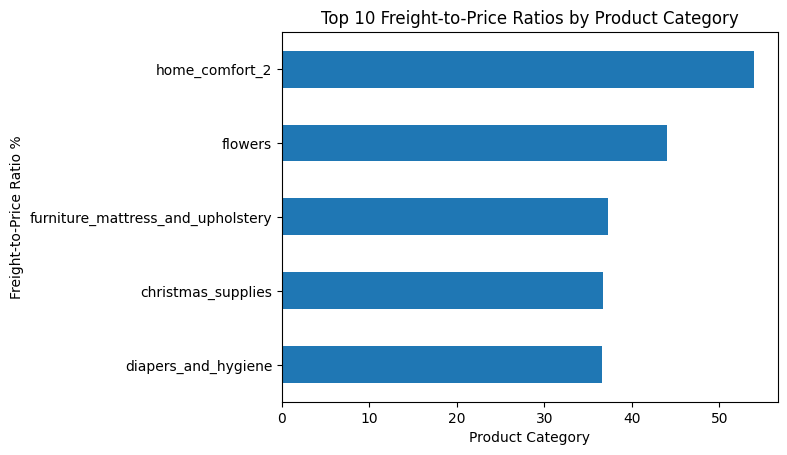

In [279]:
cat.sort_values(by="freight_ratio").tail(5)["freight_ratio"].plot(kind="barh")
plt.title("Top 10 Freight-to-Price Ratios by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Freight-to-Price Ratio %")
plt.xticks(rotation=0)

plt.show()

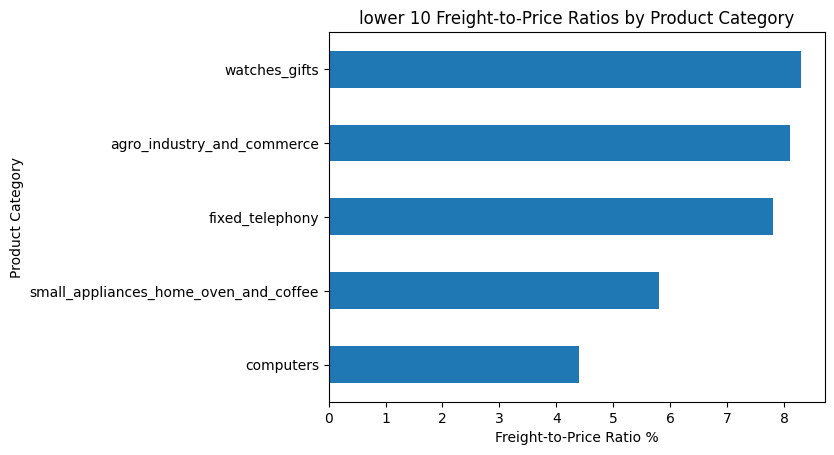

In [280]:
cat.sort_values(by="freight_ratio").head(5)["freight_ratio"].plot(kind="barh")
plt.title("lower 10 Freight-to-Price Ratios by Product Category")
plt.ylabel("Product Category")
plt.xlabel("Freight-to-Price Ratio %")
plt.xticks(rotation=0)
plt.show()

## By states

In [281]:
#merge the id 
item_state=item.merge(orders[["order_id","customer_id"]],on="order_id",how="left")

In [282]:
# merge the customers state :
item_state = item_state.merge(customers[["customer_id","state_name"]], on="customer_id" , how="left")

In [283]:
# make data frame :
state=item_state.groupby("state_name").agg(items=("order_id", "count"),freight=("freight_value","sum"),price=("price", "sum"),freight_mean=("freight_value", "mean"),
price_mean=("price", "mean"))

In [284]:
# calc the ratio by state:
state["freight_ratio"]= (state["freight"] /state["price"]).round(3) * 100

In [285]:
state.sort_values(by="freight_ratio", ascending=False).head(10)

,items,freight,price,freight_mean,price_mean,freight_ratio
state_name,,,,,,
Roraima,52,2235.19,7829.43,42.984423,150.565962,28.5
Maranhao,820,31368.72,119443.65,38.254537,145.662988,26.3
Rondonia,278,11417.38,46140.64,41.069712,165.973525,24.7
Amazonas,165,5478.89,22356.84,33.205394,135.496000,24.5
Piaui,539,21066.06,86641.18,39.083599,160.744304,24.3
Sergipe,384,14088.20,58842.85,36.688021,153.236589,23.9
Tocantins,314,11629.56,49441.84,37.036815,157.458089,23.5
Acre,92,3686.75,15982.95,40.073370,173.727717,23.1
Rio Grande do Norte,529,18860.10,83034.98,35.652363,156.965936,22.7


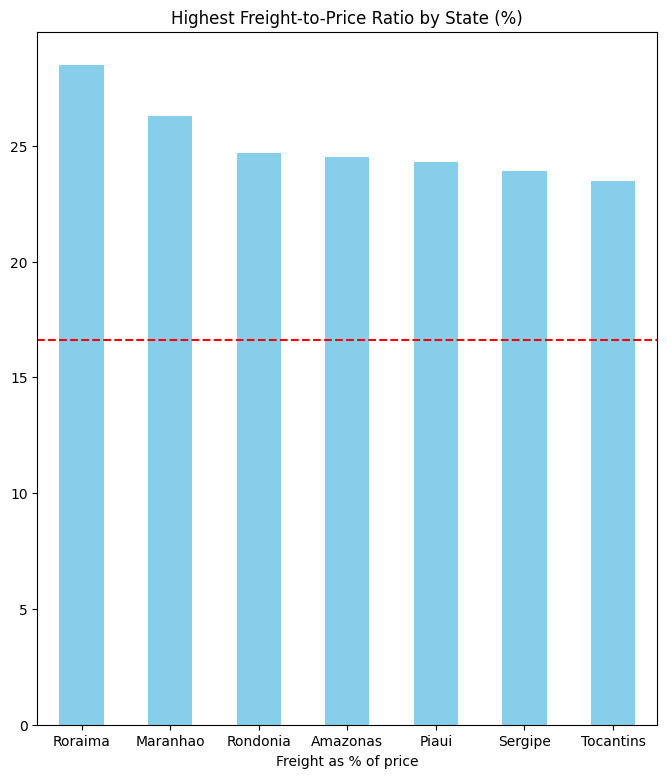

In [286]:
plot_state = state.drop("international")["freight_ratio"].sort_values(ascending=False).head(7).plot(kind="bar", color="skyblue", figsize=(8, 9))
plt.axhline(16.6, color="red", linestyle="--")
plt.title("Highest Freight-to-Price Ratio by State (%)")
plt.xlabel("Freight as % of price")
plt.xticks(rotation=0)

plt.show()

## Q3
Are lighter products being overcharged (e.g., low weight but high freight)

In [287]:
# merged item with weight
item_weight = item.merge(products[["product_id", "product_weight_g"]], on="product_id", how="left")

In [288]:
print(item_weight["product_weight_g"].isna().sum())     
print((item_weight["product_weight_g"] == 0).sum())      

18
8


In [289]:
# filter the data :
item_weight=item_weight[item_weight["product_weight_g"] > 0].copy()
len(item_weight)

112620

In [290]:
# to find max , min of weight
item_weight["product_weight_g"].describe()

count    112620.000000
mean       2093.550169
std        3751.346883
min           2.000000
25%         300.000000
50%         700.000000
75%        1800.000000
max       40425.000000
Name: product_weight_g, dtype: float64

In [291]:
# make group for weight :
item_weight["weight_group"] = pd.cut(item_weight["product_weight_g"], bins=[0, 300, 700, 1800, 5000, float("inf")], labels=["<300g", "300-700g", "700-1800g", "1800-5000g", ">5000g"])


In [292]:
print(item_weight["weight_group"].value_counts().sort_index())

weight_group
<300g         31741
300-700g      26261
700-1800g     26858
1800-5000g    13871
>5000g        13889
Name: count, dtype: int64


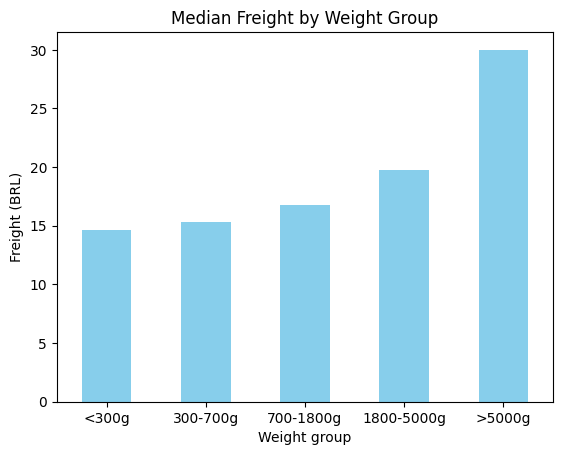

In [293]:
item_weight.groupby("weight_group", observed=True)["freight_value"].median().plot(kind="bar", color="skyblue")
plt.title("Median Freight by Weight Group")
plt.xlabel("Weight group")
plt.ylabel("Freight (BRL)")
plt.xticks(rotation=0)
plt.show()

# Q4 
How does distance between seller and customer impact freight value and delay?

In [296]:
geolocation=pd.read_csv("../Data_Cleaning/olist_geolocation_dataset_cleaned.csv")

In [297]:
# for each zip code:
geo = geolocation.groupby("geolocation_zip_code_prefix").agg( latitude=("geolocation_lat", "mean"),longitude=("geolocation_lng", "mean")).reset_index()

In [298]:
seller_location = sellers.merge(geo,left_on="seller_zip_code_prefix",right_on="geolocation_zip_code_prefix",how="left")

In [299]:
item_seller = item.merge(sellers[["seller_id", "seller_zip_code_prefix"]], on="seller_id", how="left")
# every order : not every item
order_seller_zip = item_seller.drop_duplicates(subset="order_id", keep="first")[["order_id", "seller_zip_code_prefix"]]

In [300]:
#add customer zip code in delirved dataframe
dist= delivered[["order_id", "customer_id", "status"]].merge(customers[["customer_id", "customer_zip_code_prefix"]], on="customer_id",how="left")

In [301]:
dist = dist.merge(order_seller_zip, on="order_id", how="left")

In [302]:
#except international
geo= geolocation[geolocation["state_name"] != "international"]
location= geo.groupby("geolocation_zip_code_prefix")[["geolocation_lat", "geolocation_lng"]].median()

In [303]:
# rename
cust_location= location.rename(columns={"geolocation_lat": "cust_lat", "geolocation_lng": "cust_lng"})

In [304]:
# merge with the customer:
dist = dist.merge(cust_location, left_on="customer_zip_code_prefix", right_index=True, how="left")

In [305]:
# then , the location of sellers : rename to be diffrent col
sell_location= location.rename(columns={"geolocation_lat": "sell_lat", "geolocation_lng": "sell_lng"})

In [306]:
# then , merge them :
dist = dist.merge(sell_location,left_on="seller_zip_code_prefix", right_index=True, how="left")

In [307]:
# convert them to  radius:
lat_cust= np.radians(dist["cust_lat"])
lng_cust= np.radians(dist["cust_lng"])
lat_sell= np.radians(dist["sell_lat"])
lng_sell= np.radians(dist["sell_lng"])

In [308]:
#Haversine formula from google:
km=np.sin((lat_sell - lat_cust) / 2) ** 2 + np.cos(lat_cust) * np.cos(lat_sell) * np.sin((lng_sell - lng_cust) / 2) ** 2
dist["distance_km"]= 2 * 6371 * np.arcsin(np.sqrt(km))

In [309]:
# grouping the distance:
dist["distance_group"]=pd.cut(dist["distance_km"], bins=[-1, 100, 300, 700, 1500, float("inf")], labels=["<100km", "100-300km", "300-700km", "700-1500km", ">1500km"])

In [310]:
# before merge the price - value :
totalcost=item.groupby("order_id").agg(freight_value=("freight_value", "sum"),price=("price", "sum"))

In [311]:
dist=dist.merge(totalcost,on="order_id",how="left")

In [312]:
dist_freight = dist.groupby("distance_group")["freight_value"].mean()
dist_freight

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37640\229719814.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_freight = dist.groupby("distance_group")["freight_value"].mean()


distance_group
<100km        13.451824
100-300km     18.747591
300-700km     22.718233
700-1500km    26.443569
>1500km       39.886903
Name: freight_value, dtype: float64

In [313]:
#Freight rises steadily with distance: orders under 100 km pay an average of 13.45 BRL versus 39.89 BRL beyond 1,500 km, almost three times as much.

In [314]:
dist_delay =(dist.groupby("distance_group")["status"].apply(lambda x: (x == "Delay").mean() * 100))
dist_delay

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_37640\2639931661.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dist_delay =(dist.groupby("distance_group")["status"].apply(lambda x: (x == "Delay").mean() * 100))


distance_group
<100km         4.455390
100-300km      5.194513
300-700km      6.963534
700-1500km     7.416038
>1500km       11.655811
Name: status, dtype: float64

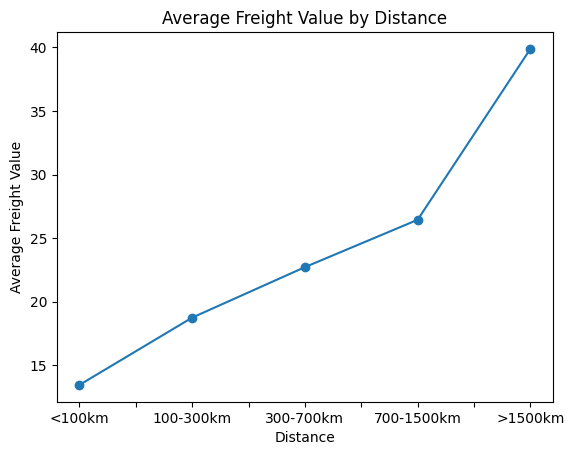

In [315]:
# plot for dist and freight value 
dist_freight.plot(kind="line", marker="o")
plt.title("Average Freight Value by Distance")
plt.xlabel("Distance")
plt.ylabel("Average Freight Value")
plt.xticks(rotation=0)
plt.show()

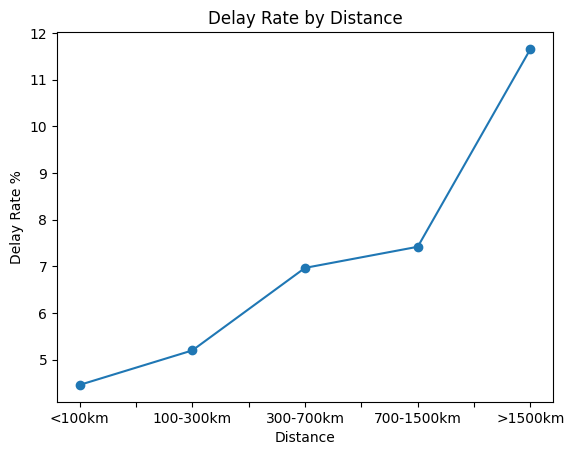

In [316]:
# plot between dist and delay
dist_delay.plot(kind="line", marker="o")
plt.title("Delay Rate by Distance")
plt.xlabel("Distance")
plt.ylabel("Delay Rate %")
plt.xticks(rotation=0)
plt.show()

In [317]:
## Both freight and delay rise with distance: orders under 100 km pay 13.45 BRL on average with a 4.5% delay rate, versus 39.89 BRL and 11.7% beyond
# 1,500 km. Distance explains part of the delay, but not all of it: some Northeastern states exceed the delay rate of the farthest distance group

# Q5
Is the underestimation of delivery time or cost a frequent issue, and why does it occur?

In [318]:
# the different between purchase date and estimate date
delivered["orders_days"]=(delivered["order_estimated_delivery_date"]- delivered["order_purchase_timestamp"]).dt.days

In [319]:
# Take the median if there any out of range values :
# estimate range
print( "median promised=", delivered["orders_days"].median())
# real range
print("median actual=",delivered["delivery_days"].median())

median promised= 23.0
median actual= 10.0


In [320]:
diffrent= {"Actual Delivery":delivered["delivery_days"].median(), 
           "Estimated Delivery":delivered["orders_days"].median()}

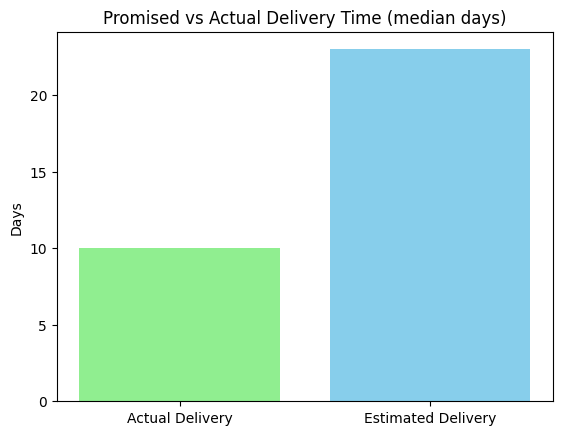

In [321]:
plt.bar(diffrent.keys(),diffrent.values(), color=["lightgreen", "skyblue"])
plt.title("Promised vs Actual Delivery Time (median days)")
plt.ylabel("Days")
plt.show()